<a href="https://colab.research.google.com/github/YarikBalkin/my/blob/main/Full_graff_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Поєднання SWOT

In [ ]:
import hashlib
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

In [ ]:
import json
import os
import re

def get_mapping_from_selection(file_path):
    """Парсить файл selection_12 для отримання мапи A1 -> Global_ID"""
    mapping = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            # Пошук рядків типу 'A1. 164.' або 'A1. 49.'
            matches = re.findall(r"(A\d+)\.\s+(\d+)\.", content)
            for local_id, global_id in matches:
                mapping[local_id] = global_id
    except Exception as e:
        print(f"Помилка при читанні файлу {file_path}: {e}")
    return mapping

def clean_suffix(filename, prefix):
    """Витягує чистий ідентифікатор, ігноруючи розширення та пробіли"""
    name = os.path.splitext(filename)[0] # Видаляємо .txt або .json
    suffix = name.replace(prefix, "").strip() # Видаляємо SWOT_JSON або selection_12
    return suffix

def compose_swot_all_robust():
    swot_folder = "/content/SWOT_JSON"
    selection_folder = "/content/selection_12"
    swot_all = []

    # 1. Спочатку створюємо "карту" дешифраторів за їхніми суфіксами
    selection_map = {}
    if not os.path.exists(selection_folder):
        print(f"Папка {selection_folder} не знайдена!")
        return

    for s_file in os.listdir(selection_folder):
        if s_file.startswith(".") or not s_file.startswith("selection_12"): continue
        suffix = clean_suffix(s_file, "selection_12")
        selection_map[suffix] = os.path.join(selection_folder, s_file)

    print(f"Проіндексовано дешифраторів: {len(selection_map)}")

    # 2. Обробляємо SWOT файли
    if not os.path.exists(swot_folder):
        print(f"Папка {swot_folder} не знайдена!")
        return

    swot_files = os.listdir(swot_folder)
    processed_count = 0

    for swot_filename in swot_files:
        if swot_filename.startswith("."): continue

        # Витягуємо суфікс (наприклад, "(1)")
        suffix = clean_suffix(swot_filename, "SWOT_JSON")

        # Шукаємо відповідний дешифратор у нашій карті
        if suffix in selection_map:
            selection_path = selection_map[suffix]
            mapping = get_mapping_from_selection(selection_path)

            # Читаємо SWOT
            swot_path = os.path.join(swot_folder, swot_filename)
            try:
                with open(swot_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                student_name = data.get('student', {}).get('name', f"Student_{suffix}")

                for factor in data.get('factors', []):
                    local_alts = factor.get('linked_alternatives', [])
                    # Дешифруємо A1 -> 164[cite: 12]
                    global_alts = [mapping.get(alt, alt) for alt in local_alts]

                    swot_all.append({
                        "global_id": f"{factor['id']}_{suffix}",
                        "student": student_name,
                        "quadrant": factor.get('quadrant'), # S, W, O, T[cite: 7]
                        "swot_sign": factor.get('swot_sign'), # 1 або -1[cite: 8]
                        "label": factor.get('label'),
                        "linked_strategies": global_alts, # Глобальні індекси[cite: 1, 12]
                        "description": factor.get('description')
                    })
                processed_count += 1
            except Exception as e:
                print(f"Помилка обробки файлу {swot_filename}: {e}")
        else:
            print(f"Пропущено: не знайдено дешифратор для суфікса '{suffix}'")

    # 3. Зберігаємо результат
    with open('SWOT_ALL.json', 'w', encoding='utf-8') as f:
        json.dump(swot_all, f, ensure_ascii=False, indent=2)

    print(f"--- РЕЗУЛЬТАТ ---")
    print(f"Оброблено робіт: {processed_count}")
    print(f"Всього факторів в SWOT_ALL.json: {len(swot_all)}")

# Запуск
compose_swot_all_robust()

Проіндексовано дешифраторів: 61
Помилка обробки файлу SWOT_JSON (29).txt: Unexpected UTF-8 BOM (decode using utf-8-sig): line 1 column 1 (char 0)
Помилка обробки файлу SWOT_JSON (7).txt: Unexpected UTF-8 BOM (decode using utf-8-sig): line 1 column 1 (char 0)
Помилка обробки файлу SWOT_JSON (9).txt: 'list' object has no attribute 'get'
--- РЕЗУЛЬТАТ ---
Оброблено робіт: 58
Всього факторів в SWOT_ALL.json: 776


# Поєднання TOWS та DELPHI


In [ ]:
import json
import os
import re

def get_mapping_from_selection(file_path):
    mapping = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            matches = re.findall(r"(A\d+)\.\s+(\d+)\.", content)
            for local_id, global_id in matches:
                mapping[local_id] = global_id
    except: pass
    return mapping

def get_swot_map(swot_path, selection_map):
    """Створює словник: локальний фактор (S1) -> список глобальних стратегій [164, 7]"""
    swot_to_global = {}
    try:
        with open(swot_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            for factor in data.get('factors', []):
                local_alts = factor.get('linked_alternatives', [])
                global_alts = [selection_map.get(alt, alt) for alt in local_alts]
                swot_to_global[factor['id']] = global_alts
    except: pass
    return swot_to_global

def clean_suffix(filename, prefix):
    name = os.path.splitext(filename)[0]
    return name.replace(prefix, "").strip()

def process_edges(folder_name, prefix, selection_folders_map, swot_folders_map):
    all_data = []
    folder_path = f"/content/{folder_name}"

    if not os.path.exists(folder_path):
        print(f"Папка {folder_name} не знайдена!")
        return []

    files = os.listdir(folder_path)
    for filename in files:
        if filename.startswith("."): continue
        suffix = clean_suffix(filename, prefix)

        # Отримуємо карти дешифрування для цього студента
        selection_map = selection_folders_map.get(suffix, {})
        swot_map = swot_folders_map.get(suffix, {})

        file_path = os.path.join(folder_path, filename)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            # Обробка списку ребер (у TOWS це 'matrix_raw', у Delphi - 'edges_raw')
            edges = data.get('matrix_raw') or data.get('edges_raw') or data.get('edges_delphi', [])

            for edge in edges:
                # Визначаємо ключі джерела і цілі (вони можуть відрізнятися в TOWS/Delphi)
                src_key = 'source_factor' if 'source_factor' in edge else 'source'
                tgt_key = 'target_factor' if 'target_factor' in edge else 'target'

                src_id = edge.get(src_key)
                tgt_id = edge.get(tgt_key)

                # Додаємо глобальні посилання
                edge['global_source_strategies'] = swot_map.get(src_id, [])
                edge['global_target_strategies'] = swot_map.get(tgt_id, [])
                edge['student_suffix'] = suffix

                all_data.append(edge)
        except Exception as e:
            print(f"Помилка у файлі {filename}: {e}")

    return all_data

# --- ОСНОВНИЙ ЦИКЛ ЗБОРУ ---

# 1. Індексуємо дешифратори
selection_map_global = {}
for f in os.listdir("/content/selection_12"):
    if not f.startswith("."):
        suffix = clean_suffix(f, "selection_12")
        selection_map_global[suffix] = get_mapping_from_selection(f"/content/selection_12/{f}")

# 2. Індексуємо SWOT-карти (потрібні для розуміння, які стратегії стоять за S1, W1...)
swot_map_global = {}
for f in os.listdir("/content/SWOT_JSON"):
    if not f.startswith("."):
        suffix = clean_suffix(f, "SWOT_JSON")
        swot_map_global[suffix] = get_swot_map(f"/content/SWOT_JSON/{f}", selection_map_global.get(suffix, {}))

# 3. Зшиваємо TOWS
tows_all = process_edges("TOWS_FULL_JSON", "TOWS_FULL_JSON", selection_map_global, swot_map_global)
with open('TOWS_ALL.json', 'w', encoding='utf-8') as f:
    json.dump(tows_all, f, ensure_ascii=False, indent=2)

# 4. Зшиваємо Delphi
delphi_all = process_edges("DELPHI_EDGES_JSON", "DELPHI_EDGES_JSON", selection_map_global, swot_map_global)
with open('DELPHI_ALL.json', 'w', encoding='utf-8') as f:
    json.dump(delphi_all, f, ensure_ascii=False, indent=2)

print(f"Об'єднання завершено!")
print(f"TOWS_ALL: {len(tows_all)} ребер")
print(f"DELPHI_ALL: {len(delphi_all)} ребер")

Помилка у файлі TOWS_FULL_JSON (22).txt: Expecting ',' delimiter: line 161 column 5 (char 4728)
Помилка у файлі TOWS_FULL_JSON (7).txt: Unexpected UTF-8 BOM (decode using utf-8-sig): line 1 column 1 (char 0)
Помилка у файлі TOWS_FULL_JSON (37).txt: Expecting ',' delimiter: line 13 column 178 (char 1726)
Помилка у файлі TOWS_FULL_JSON (43).txt: Expecting value: line 14 column 28 (char 334)
Помилка у файлі TOWS_FULL_JSON (29).txt: Unexpected UTF-8 BOM (decode using utf-8-sig): line 1 column 1 (char 0)
Помилка у файлі TOWS_FULL_JSON (9).txt: 'list' object has no attribute 'get'
Помилка у файлі DELPHI_EDGES_JSON (7).txt: Unexpected UTF-8 BOM (decode using utf-8-sig): line 1 column 1 (char 0)
Помилка у файлі DELPHI_EDGES_JSON (9).txt: 'list' object has no attribute 'get'
Помилка у файлі DELPHI_EDGES_JSON (21).txt: Expecting ',' delimiter: line 197 column 10 (char 5613)
Помилка у файлі DELPHI_EDGES_JSON (29).txt: Unexpected UTF-8 BOM (decode using utf-8-sig): line 1 column 1 (char 0)
Об'єдна

# G_Mega 3

In [17]:
import json
import networkx as nx

# Ініціалізація орієнтованого графа
G = nx.DiGraph()

# Завантажуємо агреговану базу SWOT
with open('SWOT_ALL.json', 'r', encoding='utf-8') as f:
    swot_all = json.load(f)

for factor in swot_all:
    # Використовуємо глобальний ID як ім'я вузла
    node_id = factor['global_id']

    # ФІКС KeyError 's': примусово переводимо квадрант у верхній регістр
    quad = str(factor['quadrant']).upper()

    G.add_node(
        node_id,
        quadrant=quad,
        label=factor.get('label', 'N/A'),
        swot_sign=factor.get('swot_sign', 1),
        student=factor.get('student', 'Unknown')
    )

print(f"✅ Крок 1 завершено: Створено {G.number_of_nodes()} унікальних вузлів.")
print(f"Приклад вузла: {list(G.nodes())[0]}")

✅ Крок 1 завершено: Створено 776 унікальних вузлів.
Приклад вузла: S1_(26)


In [30]:
# Завантажуємо агреговану базу Delphi
with open('DELPHI_ALL.json', 'r', encoding='utf-8') as f:
    delphi_all = json.load(f)

edges_count = 0
skipped_count = 0

for edge in delphi_all:
    # Отримуємо суфікс студента
    suffix = edge.get('student_suffix', '')

    # Пробуємо різні варіанти назв ключів для джерела та цілі
    src_local = edge.get('source') or edge.get('source_factor')
    tgt_local = edge.get('target') or edge.get('target_factor')

    if src_local and tgt_local:
        # Реконструюємо повний ID (наприклад, S1_(59))
        src_id = f"{src_local}_{suffix}"
        tgt_id = f"{tgt_local}_{suffix}"

        # Додаємо ребро тільки якщо обидва вузли існують у графі G
        if src_id in G and tgt_id in G:

            # Отримуємо об'єкт результату Delphi
            res = edge.get('delphi_result')

            if res and isinstance(res, dict):
                # Беремо ТІЛЬКИ фінальну вагу та знак
                w = res.get('final_weight_center')
                s = res.get('final_sign')

                # Додаємо ребро лише якщо вага існує в даних
                if w is not None:
                    G.add_edge(src_id, tgt_id, weight=float(w), sign=int(s or 1))
                    edges_count += 1
                else:
                    skipped_count += 1
            else:
                skipped_count += 1
        else:
            skipped_count += 1

print(f"✅ Крок 2 завершено!")
print(f"   - Побудовано ребер (з фінальними вагами): {edges_count}")
print(f"   - Пропущено записів (без ваг або вузлів): {skipped_count}")

✅ Крок 2 завершено!
   - Побудовано ребер (з фінальними вагами): 1197
   - Пропущено записів (без ваг або вузлів): 68


In [31]:
# Перевірка перших 3-х ребер
for i, (u, v, d) in enumerate(G.edges(data=True)):
    print(f"Зв'язок: {u} -> {v} | Вага: {d['weight']} | Знак: {d['sign']}")
    if i >= 10: break

Зв'язок: S1_(26) -> O1_(26) | Вага: 0.74 | Знак: 1
Зв'язок: S1_(26) -> T1_(26) | Вага: 0.77 | Знак: -1
Зв'язок: S2_(26) -> O3_(26) | Вага: 0.77 | Знак: 1
Зв'язок: S2_(26) -> T2_(26) | Вага: 0.81 | Знак: -1
Зв'язок: S3_(26) -> O1_(26) | Вага: 0.69 | Знак: 1
Зв'язок: S3_(26) -> T1_(26) | Вага: 0.75 | Знак: -1
Зв'язок: S4_(26) -> O2_(26) | Вага: 0.76 | Знак: 1
Зв'язок: S4_(26) -> T2_(26) | Вага: 0.79 | Знак: -1
Зв'язок: S5_(26) -> T1_(26) | Вага: 0.7 | Знак: -1
Зв'язок: O1_(26) -> W3_(26) | Вага: 0.82 | Знак: -1
Зв'язок: O1_(26) -> W4_(26) | Вага: 0.71 | Знак: -1


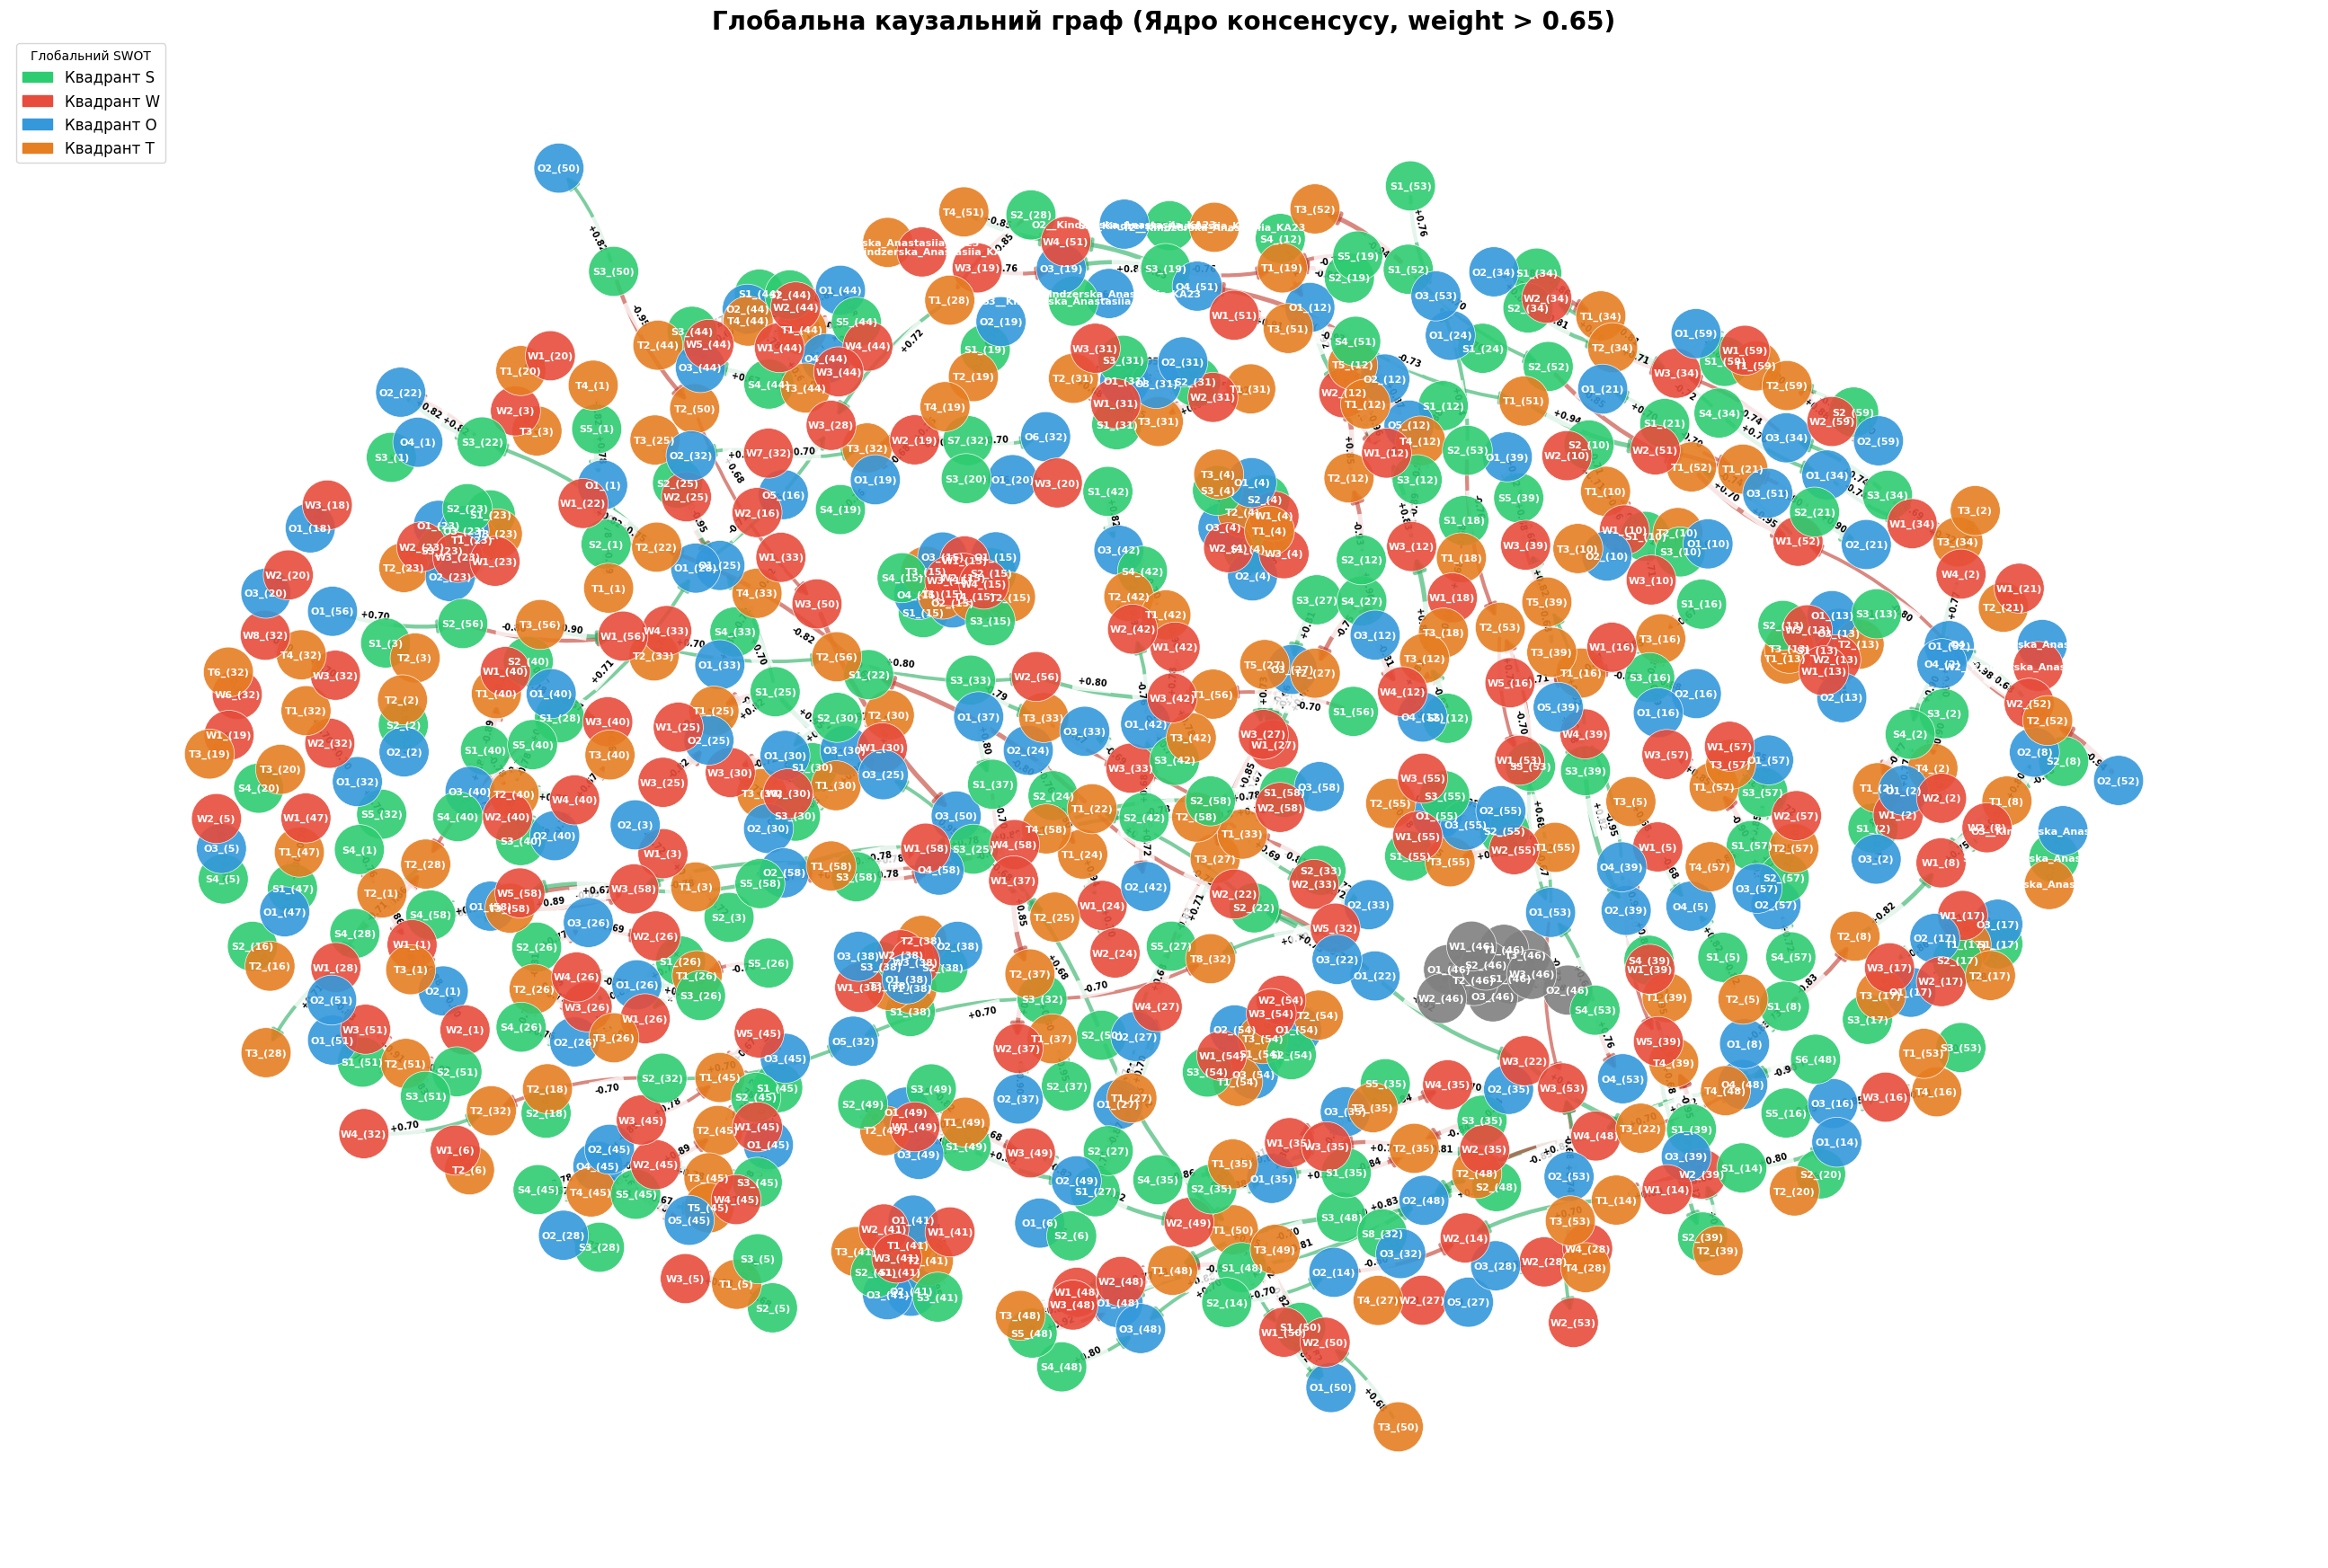

✅ Успішно побудовано 'Ядро системи' (685 вузлів, 936 ребер).


In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. ПІДГОТОВКА ДАНИХ ДЛЯ ВІЗУАЛІЗАЦІЇ ---

# Створюємо підграф (Core Graph) для візуалізації, щоб уникнути "каші"
# Ми залишаємо тільки найсильніші зв'язки (вага > threshold)
threshold = 0.65
G_vis = nx.DiGraph()

# Додаємо ребра, які проходять фільтр
strong_edges = []
for u, v, d in G.edges(data=True):
    if d['weight'] > threshold:
        G_vis.add_edge(u, v, weight=d['weight'], sign=d['sign'])
        strong_edges.append((u, v))

# Додаємо вузли з атрибутами (тільки ті, що мають сильні зв'язки)
valid_nodes = set(list(G_vis.nodes()))
for factor in swot_all:
    node_id = factor['global_id']
    if node_id in valid_nodes:
        quad = str(factor['quadrant']).upper()
        G_vis.add_node(node_id, quadrant=quad, label=factor['label'])

# --- 2. ЕСТЕТИЧНА ВІЗУАЛІЗАЦІЯ (СТИЛЬ СТУДЕНТА) ---

plt.figure(figsize=(26, 18), dpi=100)

# Використовуємо кастомний layout для кращого розподілу семантичних груп
pos = nx.spring_layout(G_vis, k=0.25, iterations=150, seed=42)

color_map_nodes = {'S': '#2ecc71', 'W': '#e74c3c', 'O': '#3498db', 'T': '#e67e22'}
edge_color_pos = '#27ae60' # Зелений Nephritis (+)
edge_color_neg = '#c0392b' # Червоний Pomegranate (-)

# Отримуємо списки атрибутів для малювання
nodes_to_draw = list(G_vis.nodes())
edges_to_draw = list(G_vis.edges(data=True))

node_colors = [color_map_nodes.get(G_vis.nodes[n].get('quadrant'), 'gray') for n in nodes_to_draw]
edge_colors = [edge_color_pos if d['sign'] == 1 else edge_color_neg for _, _, d in edges_to_draw]
edge_widths = [d['weight'] * 4 for _, _, d in edges_to_draw] # Масштабування як у студента

# Малювання вузлів (збільшуємо розмір для глобального масштабу)
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=1600, alpha=0.9, edgecolors='white', linewidths=0.5)

# Малювання підписів (тільки ID: S1_(59))
nx.draw_networkx_labels(G_vis, pos, font_size=8, font_weight='bold', font_color='white', font_family='sans-serif')

# Малювання ребер з вигином (connectionstyle arc3)
nx.draw_networkx_edges(G_vis, pos, edgelist=strong_edges, edge_color=edge_colors, width=edge_widths,
                       alpha=0.6, arrowsize=20, connectionstyle='arc3,rad=0.12')

# Малювання підписів ребер (+0.80 тощо)
edge_labels = {(u, v): f"{'+' if d['sign']==1 else '-'}{d['weight']:.2f}"
               for u, v, d in edges_to_draw}
nx.draw_networkx_edge_labels(G_vis, pos, edge_labels=edge_labels, font_size=7, font_weight='bold',
                             label_pos=0.3, bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# Створення легенди
legend_handles = [mpatches.Patch(color=color, label=f"Квадрант {quad}") for quad, color in color_map_nodes.items()]
plt.legend(handles=legend_handles, title="Глобальний SWOT", loc='upper left', fontsize=12)

plt.title(f"Глобальна каузальний граф (Ядро консенсусу, weight > {threshold})", fontsize=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.subplots_adjust(top=0.95) # Залишаємо місце для заголовка
plt.show()

print(f"✅ Успішно побудовано 'Ядро системи' ({G_vis.number_of_nodes()} вузлів, {G_vis.number_of_edges()} ребер).")

## Інтеграція нового графа

In [45]:
import networkx as nx
from itertools import combinations
from collections import defaultdict

# --- 1. ПІДГОТОВКА: Мапування "Альтернатива -> Вузли" ---
# Створюємо словник, де кожна стратегія збирає навколо себе всі SWOT-фактори
strat_to_nodes = defaultdict(list)

for item in swot_all:
    g_id = item['global_id']
    linked_strats = item.get('linked_strategies', [])
    for s_id in linked_strats:
        strat_to_nodes[str(s_id)].append(g_id)

# --- 2. ПОБУДОВА НОВОГО ГРАФА G_integrated ---
# Копіюємо існуючий граф, щоб не втратити прямі TOWS-зв'язки
G_integrated = G_vis.copy()

# Параметри містка
BRIDGE_WEIGHT = 0.8  # Вага консенсусу
new_bridges_count = 0
inter_author_links = 0

print("🔗 Починаємо процес зшивання графа через стратегічні альтернативи...")

# --- 3. ГЕНЕРАЦІЯ МІСТКІВ ---
for s_id, nodes in strat_to_nodes.items():
    if len(nodes) > 1:
        # Створюємо зв'язки між усіма парами вузлів, що мають спільну стратегію
        for u, v in combinations(nodes, 2):
            if u != v:
                # Визначаємо, чи це різні автори
                author_u = u.split('_')[-1]
                author_v = v.split('_')[-1]

                # Додаємо ребро, якщо його ще немає, або підсилюємо існуюче
                if not G_integrated.has_edge(u, v):
                    G_integrated.add_edge(u, v,
                                          weight=BRIDGE_WEIGHT,
                                          edge_type='strategic_bridge',
                                          strategy_ref=s_id)
                    new_bridges_count += 1
                    if author_u != author_v:
                        inter_author_links += 1

# --- 4. ПЕРЕВІРКА РЕЗУЛЬТАТІВ ---
print(f"\n✅ Побудову оновленого графа завершено!")
print(f"   • Додано стратегічних містків: {new_bridges_count}")
print(f"   • З них з'єднують РІЗНИХ авторів: {inter_author_links}")
print(f"   • Загальна кількість ребер у новому графі: {G_integrated.number_of_edges()}")

# Оновлюємо посилання на граф для наступних етапів
G_vis = G_integrated

🔗 Починаємо процес зшивання графа через стратегічні альтернативи...

✅ Побудову оновленого графа завершено!
   • Додано стратегічних містків: 0
   • З них з'єднують РІЗНИХ авторів: 0
   • Загальна кількість ребер у новому графі: 26688


Статистика інтегрованого графа:
 - TOWS-зв'язки (основні): 936
 - Стратегічні містки (нові): 25752
 - Загальна сума ребер: 26688


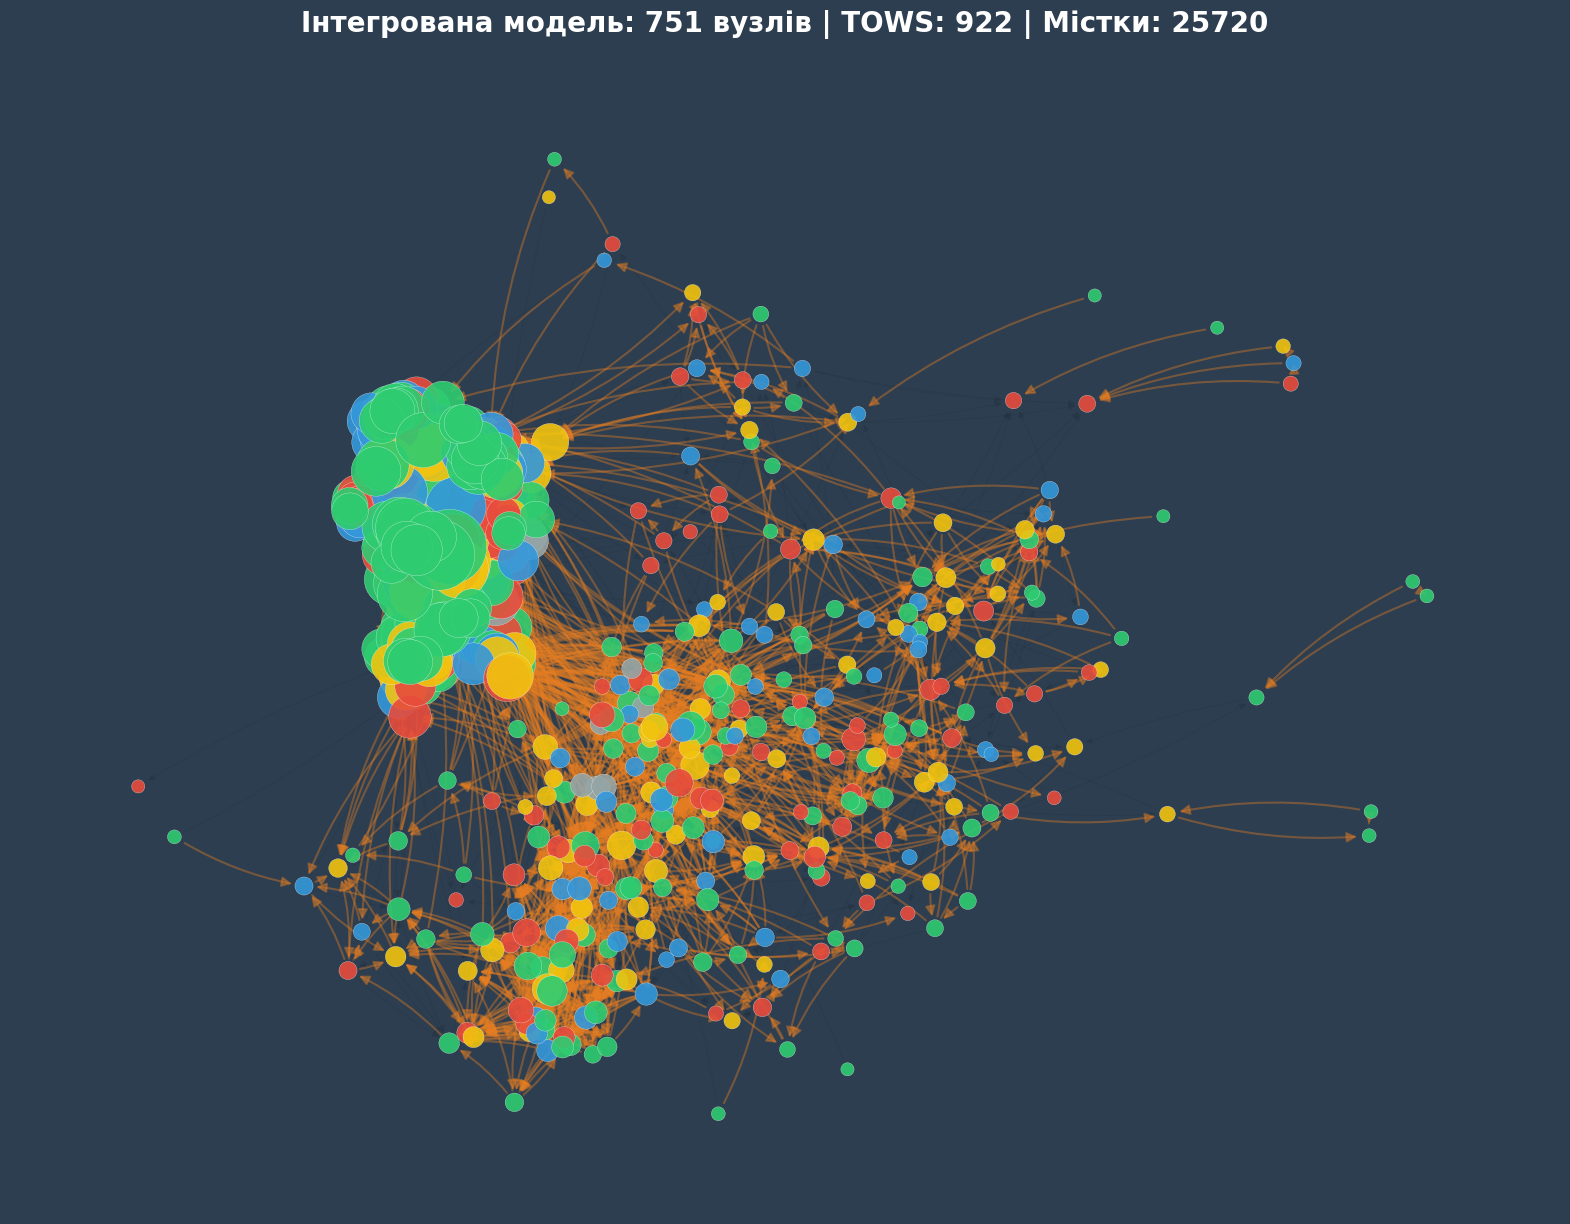

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. СТАТИСТИКА ТА ПІДГОТОВКА ---

# Визначаємо типи ребер правильно
# TOWS — це ребра, які НЕ мають типу 'strategic_bridge'
edges_tows_list = [e for e, d in G_integrated.edges.items() if d.get('edge_type') != 'strategic_bridge']
edges_bridge_list = [e for e, d in G_integrated.edges.items() if d.get('edge_type') == 'strategic_bridge']

print(f"Статистика інтегрованого графа:")
print(f" - TOWS-зв'язки (основні): {len(edges_tows_list)}")
print(f" - Стратегічні містки (нові): {len(edges_bridge_list)}")
print(f" - Загальна сума ребер: {G_integrated.number_of_edges()}")

# --- 2. ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(20, 15), facecolor='#2c3e50')
ax = plt.gca()
ax.set_facecolor('#2c3e50')

# Виділяємо Найбільшу Зв'язну Компоненту (LCC)
undirected = G_integrated.to_undirected()
lcc_nodes = max(nx.connected_components(undirected), key=len)
G_lcc = G_integrated.subgraph(lcc_nodes).copy()

# Layout
pos = nx.spring_layout(G_lcc, k=0.15, iterations=100, seed=42)

# Кольори вузлів за квадрантами
swot_colors_map = {'S': '#2ecc71', 'W': '#e74c3c', 'O': '#3498db', 'T': '#f1c40f'}
node_colors = [swot_colors_map.get(G_lcc.nodes[n].get('quadrant', 'S'), '#95a5a6') for n in G_lcc.nodes()]
node_sizes = [80 + 10 * G_lcc.degree(n) for n in G_lcc.nodes()]

# Розподіл ребер LCC за типами для малювання
l_edges_tows = [e for e, d in G_lcc.edges.items() if d.get('edge_type') != 'strategic_bridge']
l_edges_bridge = [e for e, d in G_lcc.edges.items() if d.get('edge_type') == 'strategic_bridge']

# 1. Малюємо ОСНОВНІ зв'язки (TOWS) — темні
nx.draw_networkx_edges(G_lcc, pos, edgelist=l_edges_tows,
                       alpha=0.15,
                       edge_color='#1a252f',
                       width=0.6,
                       arrows=True,
                       arrowsize=10,
                       connectionstyle='arc3,rad=0.05')

# 2. Малюємо НОВІ зв'язки (МІСТКИ) — яскраві
nx.draw_networkx_edges(G_lcc, pos, edgelist=l_edges_bridge,
                       alpha=0.4,
                       edge_color='#e67e22',
                       width=1.5,
                       arrows=True,
                       arrowsize=15,
                       connectionstyle='arc3,rad=0.1')

# 3. Малюємо вузли (без написів)
nx.draw_networkx_nodes(G_lcc, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       alpha=0.9,
                       edgecolors='white',
                       linewidths=0.2)

plt.title(f"Інтегрована модель: {G_lcc.number_of_nodes()} вузлів | TOWS: {len(l_edges_tows)} | Містки: {len(l_edges_bridge)}",
          fontsize=20, fontweight='bold', color='white', pad=20)

plt.axis('off')
plt.show()

In [ ]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

# 1. Load Data
with open('SWOT_ALL.json', 'r', encoding='utf-8') as f:
    swot_data = json.load(f)
with open('TOWS_ALL.json', 'r', encoding='utf-8') as f:
    tows_data = json.load(f)

# 2. Build Base Graph
G_integrated = nx.DiGraph()

# Nodes with quadrant
node_to_quadrant = {}
for item in swot_data:
    g_id = item['global_id']
    quad = item['quadrant'].upper()[0]
    node_to_quadrant[g_id] = quad
    G_integrated.add_node(g_id, quadrant=quad, label=item['label'])

# Base TOWS Edges (Internal logic)
for edge in tows_data:
    suffix = edge['student_suffix']
    u = f"{edge['source_factor']}_{suffix}"
    v = f"{edge['target_factor']}_{suffix}"
    w = edge.get('miller_score', 5) / 10.0
    if u in G_integrated and v in G_integrated:
        G_integrated.add_edge(u, v, weight=w, edge_type='tows_link')

# 3. Integration (Strategic Bridges - Cross-expert)
strat_to_nodes = defaultdict(list)
for item in swot_data:
    g_id = item['global_id']
    linked_strats = item.get('linked_strategies', [])
    for s_id in linked_strats:
        strat_to_nodes[str(s_id)].append(g_id)

BRIDGE_WEIGHT = 0.65
for s_id, nodes in strat_to_nodes.items():
    if len(nodes) > 1:
        for u, v in combinations(nodes, 2):
            if u != v and not G_integrated.has_edge(u, v):
                G_integrated.add_edge(u, v, weight=BRIDGE_WEIGHT, edge_type='strategic_bridge', strategy=s_id)

# 4. Visualization of LCC
undirected = G_integrated.to_undirected()
lcc_nodes = max(nx.connected_components(undirected), key=len)
G_lcc = G_integrated.subgraph(lcc_nodes).copy()

plt.figure(figsize=(24, 18), facecolor='#2c3e50')
ax = plt.gca()
ax.set_facecolor('#2c3e50')

# Force-directed layout
pos = nx.spring_layout(G_lcc, k=0.2, iterations=100, seed=42)

# SWOT Colors
swot_colors = {
    'S': '#2ecc71', # Green
    'W': '#e74c3c', # Red
    'O': '#3498db', # Blue
    'T': '#f1c40f'  # Yellow/Orange
}
node_colors = [swot_colors.get(G_lcc.nodes[n].get('quadrant'), '#95a5a6') for n in G_lcc.nodes()]
node_sizes = [150 + 20 * G_lcc.degree(n) for n in G_lcc.nodes()]

# Draw Edges
edges_tows = [e for e, d in G_lcc.edges.items() if d.get('edge_type') == 'tows_link']
edges_bridge = [e for e, d in G_lcc.edges.items() if d.get('edge_type') == 'strategic_bridge']

nx.draw_networkx_edges(G_lcc, pos, edgelist=edges_tows, alpha=0.08, edge_color='#ecf0f1', width=0.6, arrows=False)
nx.draw_networkx_edges(G_lcc, pos, edgelist=edges_bridge, alpha=0.3, edge_color='#e67e22', width=1.0, arrows=False)

# Draw Nodes
nx.draw_networkx_nodes(G_lcc, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, edgecolors='white', linewidths=0.5)

# Labels for hubs
hub_threshold = sum(dict(G_lcc.degree()).values())/len(G_lcc) * 2.5
labels = {n: n.split('_')[0] for n in G_lcc.nodes() if G_lcc.degree(n) > hub_threshold}
nx.draw_networkx_labels(G_lcc, pos, labels=labels, font_size=9, font_color='white', font_weight='bold')

plt.title("Інтегрована модель: Розподіл за SWOT-факторами\n(S-Зелений, W-Червоний, O-Синій, T-Жовтий)",
          color='white', fontsize=24, fontweight='bold')
plt.axis('off')
plt.savefig('integrated_swot_graph.png', bbox_inches='tight')
plt.close()

print(f"Nodes={G_integrated.number_of_nodes()}, Edges={G_integrated.number_of_edges()}, LCC={len(lcc_nodes)}")

Nodes=776, Edges=27253, LCC=754


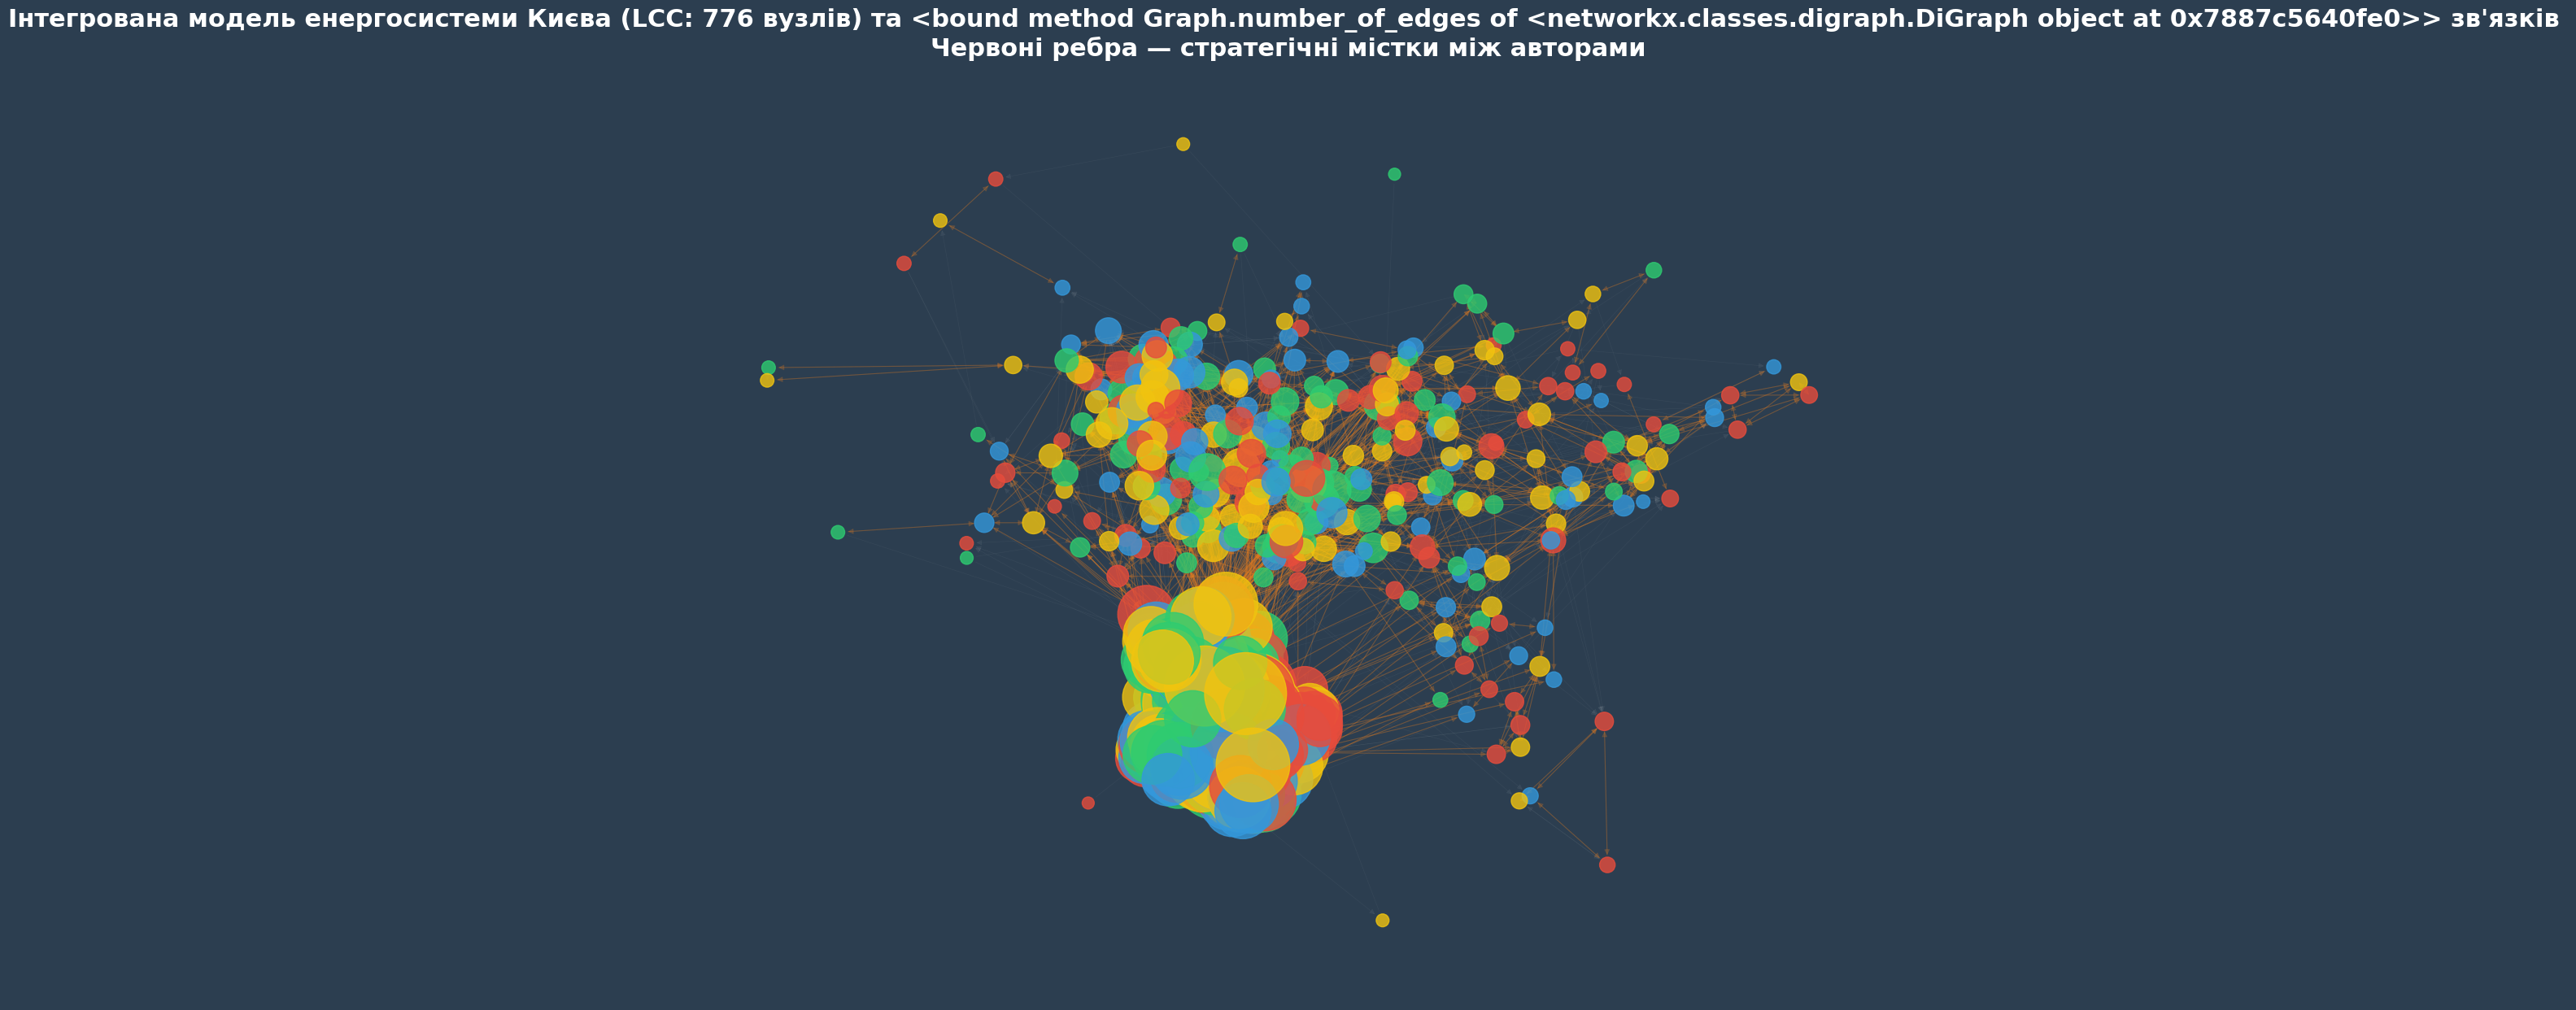

In [2]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

# --- 1. ПІДГОТОВКА ТА ЗАВАНТАЖЕННЯ ---
with open('SWOT_ALL.json', 'r', encoding='utf-8') as f:
    swot_data = json.load(f)
with open('TOWS_ALL.json', 'r', encoding='utf-8') as f:
    tows_data = json.load(f)

# Створюємо орієнтований граф
G_integrated = nx.DiGraph()

# Кольорова схема SWOT
swot_colors = {
    'S': '#2ecc71', # Зелений (Сила)
    'W': '#e74c3c', # Червоний (Слабкість)
    'O': '#3498db', # Синій (Можливість)
    'T': '#f1c40f'  # Жовтий (Загроза)
}

# --- 2. ДОДАВАННЯ ВУЗЛІВ (З АТРИБУТАМИ) ---
for item in swot_data:
    g_id = item['global_id']
    quad = item['quadrant'].upper()[0]
    G_integrated.add_node(g_id,
                          quadrant=quad,
                          label=item['label'],
                          color=swot_colors.get(quad, '#95a5a6'))

# --- 3. ВНУТРІШНІ ЗВ'ЯЗКИ (TOWS/DELPHI) ---
for edge in tows_data:
    suffix = edge['student_suffix']
    u = f"{edge['source_factor']}_{suffix}"
    v = f"{edge['target_factor']}_{suffix}"
    # Вага базується на оцінках експертів
    w = edge.get('miller_score', 5) / 10.0

    if u in G_integrated and v in G_integrated:
        G_integrated.add_edge(u, v, weight=w, edge_type='tows_link')

# --- 4. ЗШИВАННЯ ГРАФА (СТРАТЕГІЧНІ МІСТКИ) ---
# Групуємо всі вузли за ID стратегій, на які вони посилаються
strat_to_nodes = defaultdict(list)
for item in swot_data:
    g_id = item['global_id']
    for s_id in item.get('linked_strategies', []):
        strat_to_nodes[str(s_id)].append(g_id)

BRIDGE_WEIGHT = 0.80  # Вага семантичного консенсусу
for s_id, nodes in strat_to_nodes.items():
    if len(nodes) > 1:
        # З'єднуємо всі вузли, що мають спільну стратегічну альтернативу
        for u, v in combinations(nodes, 2):
            if u != v and not G_integrated.has_edge(u, v):
                # Додаємо неорієнтований місток (у обох напрямках для DiGraph)
                G_integrated.add_edge(u, v, weight=BRIDGE_WEIGHT, edge_type='strategic_bridge')
                G_integrated.add_edge(v, u, weight=BRIDGE_WEIGHT, edge_type='strategic_bridge')

# --- 5. ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(20, 15), facecolor='#2c3e50')
ax = plt.gca()
ax.set_facecolor('#2c3e50')

# Виділяємо Найбільшу Зв'язну Компоненту (LCC)
undirected = G_integrated.to_undirected()
lcc_nodes = max(nx.connected_components(undirected), key=len)
G_lcc = G_integrated.subgraph(lcc_nodes).copy()

# Layout (Spring)
pos = nx.spring_layout(G_lcc, k=0.15, iterations=100, seed=42)

# Налаштування візуальних параметрів
node_colors = [G_lcc.nodes[n]['color'] for n in G_lcc.nodes()]
node_sizes = [100 + 15 * G_lcc.degree(n) for n in G_lcc.nodes()]

# Ребра за типами
edges_tows = [e for e, d in G_lcc.edges.items() if d.get('edge_type') == 'tows_link']
edges_bridge = [e for e, d in G_lcc.edges.items() if d.get('edge_type') == 'strategic_bridge']

# Малюємо TOWS (фонові)
nx.draw_networkx_edges(G_lcc, pos, edgelist=edges_tows, alpha=0.05, edge_color='#ecf0f1', width=0.5)
# Малюємо МІСТКИ (акцентні)
nx.draw_networkx_edges(G_lcc, pos, edgelist=edges_bridge, alpha=0.2, edge_color='#e67e22', width=0.8)

# Малюємо вузли
nx.draw_networkx_nodes(G_lcc, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

plt.title("Інтегрована семантична мережа енергосистеми (Кодування SWOT)", color='white', fontsize=20)
plt.title(f"Інтегрована модель енергосистеми Києва (LCC: {G_integrated.number_of_nodes()} вузлів) та {G_integrated.number_of_edges} зв'язків \nЧервоні ребра — стратегічні містки між авторами",
          fontsize=22, fontweight='bold', color='white')
plt.axis('off')
plt.show()

In [4]:
# Рахуємо ребра за типом, який ми вказували при додаванні (edge_type)
internal_count = sum(1 for u, v, d in G_integrated.edges(data=True) if d.get('edge_type') == 'tows_link')
external_count = sum(1 for u, v, d in G_integrated.edges(data=True) if d.get('edge_type') == 'strategic_bridge')
total_count = G_integrated.number_of_edges()

print("-" * 30)
print(f"СТАТИСТИКА ГРАФА:")
print(f"Внутрішні ребра (TOWS/студенти): {internal_count}")
print(f"Зовнішні ребра (Стратегічні містки): {external_count}")
print(f"Загальна сума ребер: {total_count}")
print("-" * 30)

------------------------------
СТАТИСТИКА ГРАФА:
Внутрішні ребра (TOWS/студенти): 1528
Зовнішні ребра (Стратегічні містки): 51130
Загальна сума ребер: 52658
------------------------------


# Louvain

📊 РЕЗУЛЬТАТИ ІНТЕГРОВАНОЇ КЛАСТЕРИЗАЦІЇ:
   • Кількість знайдених макро-модулів: 7
   • Показник модулярності (Q): 0.4813
   • Розміри ТОП-5 модулів: [319, 124, 115, 114, 79]

🔍 ПЕРЕВІРКА ЕФЕКТУ ІНТЕГРАЦІЇ (Mixing Authors):
   📦 Модуль №1: 319 вузлів | Об'єднує 28 різних експертів
   📦 Модуль №2: 124 вузлів | Об'єднує 34 різних експертів
   📦 Модуль №3: 115 вузлів | Об'єднує 35 різних експертів
   📦 Модуль №4: 114 вузлів | Об'єднує 34 різних експертів
   📦 Модуль №5: 79 вузлів | Об'єднує 33 різних експертів


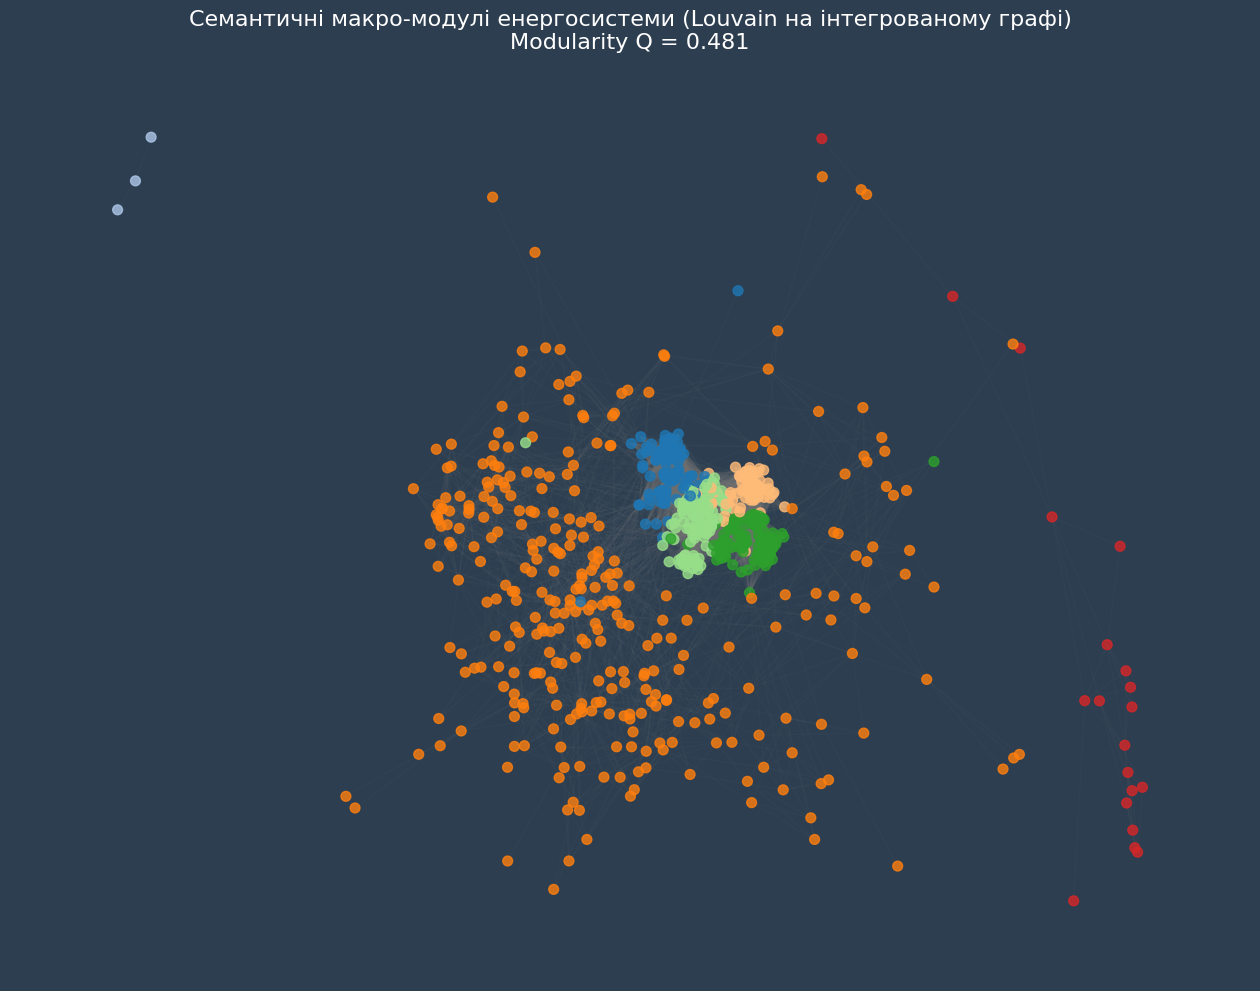

In [47]:
import community.community_louvain as community_louvain
from networkx.algorithms.community.quality import modularity

# --- 1. ЗАПУСК LOUVAIN ---
# Перетворюємо в неорієнтований для коректної роботи Louvain
G_int_undirected = G_integrated.to_undirected()

# Розрахунок розділення (partition)
partition = community_louvain.best_partition(G_int_undirected, weight='weight', random_state=42)

# Групуємо вузли за кластерами
new_louvain_comms = {}
for node, cluster_id in partition.items():
    new_louvain_comms.setdefault(cluster_id, []).append(node)

# Сортуємо кластери за розміром
sorted_comms = sorted(new_louvain_comms.values(), key=len, reverse=True)

# Розрахунок модулярності
q_score = modularity(G_int_undirected, sorted_comms)

print(f"📊 РЕЗУЛЬТАТИ ІНТЕГРОВАНОЇ КЛАСТЕРИЗАЦІЇ:")
print(f"   • Кількість знайдених макро-модулів: {len(sorted_comms)}")
print(f"   • Показник модулярності (Q): {q_score:.4f}")
print(f"   • Розміри ТОП-5 модулів: {[len(c) for c in sorted_comms[:5]]}")

# --- 2. АНАЛІЗ СКЛАДУ (ЕФЕКТ ЗШИВАННЯ) ---
print("\n🔍 ПЕРЕВІРКА ЕФЕКТУ ІНТЕГРАЦІЇ (Mixing Authors):")
for i, comm in enumerate(sorted_comms[:5]):
    authors = set([str(n).split('_')[-1] for n in comm])
    print(f"   📦 Модуль №{i+1}: {len(comm)} вузлів | Об'єднує {len(authors)} різних експертів")

# --- 3. ВІЗУАЛІЗАЦІЯ ІНТЕГРОВАНИХ КОМ'ЮНІТІ ---
plt.figure(figsize=(16, 12), facecolor='#2c3e50')
pos = nx.spring_layout(G_int_undirected, k=0.15, seed=42)

# Розфарбовуємо вузли за новими ком'юніті
cmap = plt.get_cmap('tab20')
node_colors = [cmap(partition[n] % 20) for n in G_int_undirected.nodes()]

nx.draw_networkx_nodes(G_int_undirected, pos, node_size=50, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G_int_undirected, pos, alpha=0.05, edge_color='gray')

plt.title(f"Семантичні макро-модулі енергосистеми (Louvain на інтегрованому графі)\nModularity Q = {q_score:.3f}", color='white', fontsize=16)
plt.axis('off')
plt.show()

In [ ]:
import json
import re
from collections import Counter

# --- 1. ПІДГОТОВКА МАПИ: СУФІКС -> РЕАЛЬНА РОЛЬ ---
# Ми проходимо по TOWS_ALL, щоб зрозуміти, яку роль мав кожен студент (суфікс)
suffix_to_role = {}
for edge in tows_data:
    suffix = edge.get('student_suffix')
    role = edge.get('role')
    if suffix and role:
        # Присвоюємо роль суфіксу (наприклад, "(42)" -> "Оператор / кризовий диспетчер")
        suffix_to_role[suffix] = role

print("="*85)
print(f"{'АНАЛІЗ КОМПЕТЕНЦІЙ ЕКСПЕРТІВ (ВИБІРКА З TOWS_ALL)':^85}")
print("="*85 + "\n")

# --- 2. АНАЛІЗ 7 ІНТЕГРОВАНИХ МОДУЛІВ ---
for i, comm in enumerate(sorted_comms):
    module_roles = []

    for node in comm:
        # Витягуємо суфікс із назви вузла (наприклад, "S1_(42)" -> "(42)")
        match = re.search(r'(\(\d+\))', str(node))
        if match:
            suffix = match.group(1)
            # Отримуємо реальну роль експерта для цього суфікса
            role = suffix_to_role.get(suffix, "Невизначена роль")
            module_roles.append(role)
        else:
            module_roles.append("Системний вузол")

    role_stats = Counter(module_roles)
    total_nodes = len(comm)
    unique_roles = [r for r in role_stats.keys() if r != "Невизначена роль"]

    print(f"🔷 СТРАТЕГІЧНИЙ МОДУЛЬ №{i+1}")
    print(f"   📐 Кількість факторів: {total_nodes}")
    print(f"   👥 Кількість задіяних професійних профілів: {len(unique_roles)}")
    print(f"   📊 Розподіл експертних думок за ролями:")

    # Виводимо відсоткову частку кожної ролі в модулі
    for role, count in role_stats.most_common():
        percentage = (count / total_nodes) * 100
        print(f"      - {role:.<40} {count:>3} од. ({percentage:>5.1f}%)")

    # Класифікація для дисертації
    '''
    if len(unique_roles) >= 4:
        status = "МІЖДИСЦИПЛІНАРНИЙ КОНСЕНСУС (Високий ступінь об'єктивності)"
    elif len(unique_roles) >= 2:
        status = "КООРДИНОВАНИЙ ГАЛУЗЕВИЙ ДОМЕН"
    else:
        status = "МОНО-ЕКСПЕРТНА ЗОНА (Вузька спеціалізація)"
    print(f"   💡 Статус: {status}")
    '''
    print("-" * 85 + "\n")

                  АНАЛІЗ КОМПЕТЕНЦІЙ ЕКСПЕРТІВ (ВИБІРКА З TOWS_ALL)                  

🔷 СТРАТЕГІЧНИЙ МОДУЛЬ №1
   📐 Кількість факторів: 322
   👥 Кількість задіяних професійних профілів: 12
   📊 Розподіл експертних думок за ролями:
      - Фінансово-ресурсний аналітик............  69 од. ( 21.4%)
      - Аналітик стійкості / risk & resilience expert  65 од. ( 20.2%)
      - Інженер інфраструктури..................  33 од. ( 10.2%)
      - Міський управлінець.....................  29 од. (  9.0%)
      - Фінансовий аналітик.....................  25 од. (  7.8%)
      - Міський управлінець / policy expert.....  21 од. (  6.5%)
      - Аналітик стійкості......................  20 од. (  6.2%)
      - Risk & resilience analyst...............  16 од. (  5.0%)
      - Системний критик........................  10 од. (  3.1%)
      - Невизначена роль........................  10 од. (  3.1%)
      - Системний вузол.........................   9 од. (  2.8%)
      - Аналітик.....................

In [ ]:
import json
import re
from collections import Counter

# --- 1. РОЗШИРЕНИЙ СЛОВНИК НОРМАЛІЗАЦІЇ ---
role_mapping = {
    # Аналітики
    "аналітик стійкості / risk & resilience expert": "Аналітик (Risk & Resilience)",
    "аналітик стійкості": "Аналітик (Risk & Resilience)",
    "risk & resilience analyst": "Аналітик (Risk & Resilience)",
    "risk & resilience expert": "Аналітик (Risk & Resilience)",
    "аналітик ризиків": "Аналітик (Risk & Resilience)",
    "Аналітик Стійкості": "Аналітик (Risk & Resilience)",
    "аналітик": "Аналітик (Risk & Resilience)",

    # Інженери та Проектувальники
    "технічний інженер / проектування системи": "Технічний інженер / Проектувальник",
    "інженер енергосистеми": "Технічний інженер / Проектувальник",
    "спеціаліст з проектування енергосистем": "Технічний інженер / Проектувальник",
    "інженер": "Технічний інженер / Проектувальник",

    # Менеджери та Управлінці
    "керівник проектів / менеджер з впровадження": "Менеджер проектів / Управлінець",
    "менеджер проектів": "Менеджер проектів / Управлінець",
    "project manager": "Менеджер проектів / Управлінець",
    "керівник проекту": "Менеджер проектів / Управлінець",
    "policy maker": "Управлінець / Policy maker",
    "державний управлінець / policy maker": "Управлінець / Policy maker",

    # Диспетчери та Оператори
    "оператор / кризовий диспетчер": "Оператор / Кризовий диспетчер",
    "диспетчер": "Оператор / Кризовий диспетчер",
    "диспетчер енергосистеми": "Оператор / Кризовий диспетчер",

    # Фінанси
    "фінансовий менеджер / cfo": "Фінансовий експерт / CFO",
    "cfo": "Фінансовий експерт / CFO",
    "фінансовий аналітик": "Фінансовий експерт / CFO"
}

def normalize_role(raw_role):
    if not raw_role:
        return "Не вказано"
    # Зводимо до нижнього регістру та прибираємо зайві пробіли для точного пошуку
    clean_role = raw_role.lower().strip()
    return role_mapping.get(clean_role, raw_role.strip()) # Якщо немає в списку, лишаємо оригінал

# --- 2. ПЕРЕРАХУНОК МАПИ СУФІКС -> РОЛЬ ---
suffix_to_role = {}
for edge in tows_data:
    suffix = edge.get('student_suffix')
    raw_role = edge.get('role', 'Не вказано')
    if suffix:
        suffix_to_role[suffix] = normalize_role(raw_role)

# --- 3. ПІДСУМКОВИЙ АНАЛІЗ МОДУЛІВ ---
print("="*85)
print(f"{'ФІНАЛЬНИЙ ОЧИЩЕНИЙ РОЗПОДІЛ РОЛЕЙ У МОДУЛЯХ':^85}")
print("="*85 + "\n")

for i, comm in enumerate(sorted_comms):
    module_roles = []
    for node in comm:
        match = re.search(r'(\(\d+\))', str(node))
        if match:
            s_id = match.group(1)
            role = suffix_to_role.get(s_id, "Невизначена роль")
            module_roles.append(role)

    role_stats = Counter(module_roles)
    total = len(comm)

    print(f"🔷 МОДУЛЬ №{i+1} (Розмір: {total} факторів)")
    # Виводимо всі ролі, що потрапили в цей кластер
    for role, count in role_stats.most_common():
        perc = (count / total) * 100
        print(f"   - {role:.<45} {perc:>5.1f}% ({count} од.)")
    print("-" * 60)

                     ФІНАЛЬНИЙ ОЧИЩЕНИЙ РОЗПОДІЛ РОЛЕЙ У МОДУЛЯХ                     

🔷 МОДУЛЬ №1 (Розмір: 322 факторів)
   - Аналітик (Risk & Resilience).................  33.9% (109 од.)
   - Фінансово-ресурсний аналітик.................  21.4% (69 од.)
   - Інженер інфраструктури.......................  10.2% (33 од.)
   - Міський управлінець..........................   9.0% (29 од.)
   - Фінансовий експерт / CFO.....................   7.8% (25 од.)
   - Міський управлінець / policy expert..........   6.5% (21 од.)
   - Системний критик.............................   3.1% (10 од.)
   - Невизначена роль.............................   3.1% (10 од.)
   - Оператор / Кризовий диспетчер................   2.2% (7 од.)
------------------------------------------------------------
🔷 МОДУЛЬ №2 (Розмір: 134 факторів)
   - Аналітик (Risk & Resilience).................  55.2% (74 од.)
   - Оператор / Кризовий диспетчер................   9.7% (13 од.)
   - Фінансово-ресурсний аналітик............

In [ ]:
import json
import re
from collections import Counter
import community.community_louvain as community_louvain

# --- 1. ПОВНА НОРМАЛІЗАЦІЯ РОЛЕЙ (враховуючи всі твої уточнення) ---
role_map = {
    "аналітик стійкості / risk & resilience expert": "Аналітик (Risk & Resilience)",
    "аналітик стійкості": "Аналітик (Risk & Resilience)",
    "risk & resilience analyst": "Аналітик (Risk & Resilience)",
    "risk & resilience expert": "Аналітик (Risk & Resilience)",
    "аналітик ризиків": "Аналітик (Risk & Resilience)",
    "Аналітик Стійкості": "Аналітик (Risk & Resilience)",
    "аналітик": "Аналітик (Risk & Resilience)",

    "технічний інженер / проектування системи": "Технічний інженер / Проектувальник",
    "інженер енергосистеми": "Технічний інженер / Проектувальник",
    "спеціаліст з проектування енергосистем": "Технічний інженер / Проектувальник",
    "інженер": "Технічний інженер / Проектувальник",

    "керівник проектів / менеджер з впровадження": "Менеджер проектів / Управлінець",
    "менеджер проектів": "Менеджер проектів / Управлінець",
    "project manager": "Менеджер проектів / Управлінець",
    "керівник проекту": "Менеджер проектів / Управлінець",
    "policy maker": "Управлінець / Policy maker",
    "державний управлінець / policy maker": "Управлінець / Policy maker",

    "оператор / кризовий диспетчер": "Оператор / Кризовий диспетчер",
    "диспетчер": "Оператор / Кризовий диспетчер",
    "диспетчер енергосистеми": "Оператор / Кризовий диспетчер",

    "фінансовий менеджер / cfo": "Фінансовий експерт / CFO",
    "cfo": "Фінансовий експерт / CFO",
    "фінансовий аналітик": "Фінансовий експерт / CFO"
}

# Створюємо мапу суфіксів (наприклад, "(42)" -> Роль)
suffix_to_role = {}
for edge in tows_data:
    s = edge.get('student_suffix')
    r = edge.get('role', '').strip()
    if s:
        # Шукаємо в мапі або лишаємо оригінал, якщо не знайшли
        suffix_to_role[s] = role_map.get(r) or role_map.get(r.lower()) or r or "Інший фахівець"

# --- 2. СИНХРОНІЗАЦІЯ: ПЕРЕРАХУНОК LOUVAIN НА G_INT_UNDIRECTED ---
# Робимо це тут, щоб список вузлів у ком'юніті був 100% актуальним
partition = community_louvain.best_partition(G_int_undirected, weight='weight', random_state=42)
new_comms_dict = {}
for node, c_id in partition.items():
    new_comms_dict.setdefault(c_id, []).append(node)

# Сортуємо ком'юніті за розміром (від більших до менших)
final_sorted_comms = sorted(new_comms_dict.values(), key=len, reverse=True)

# --- 3. ГЕНЕРАЦІЯ ПОВНОГО ТА ТОЧНОГО ЗВІТУ ---
print("="*105)
print(f"{'ПОВНИЙ СЕМАНТИЧНИЙ ТА ПРОФЕСІЙНИЙ ЗВІТ (SOURCE: G_INT_UNDIRECTED)':^105}")
print("="*105 + "\n")

for i, comm in enumerate(final_sorted_comms):
    # Побудова підграфа для розрахунку впливу вузла (його зв'язності всередині кластера)
    sub = G_int_undirected.subgraph(comm)
    node_impact = {n: val for n, val in sub.degree(weight='weight')}

    module_roles = []
    module_quads = []
    module_strats = set()
    semantic_data = []

    for node in comm:
        # 1. Визначення квадранта (S, W, O, T) - найнадійніший метод
        q_label = str(node)[0].upper()
        if q_label in ['S', 'W', 'O', 'T']:
            module_quads.append(q_label)

        # 2. Визначення ролі через суфікс (42)
        match = re.search(r'(\(\d+\))', str(node))
        if match:
            s_id = match.group(1)
            module_roles.append(suffix_to_role.get(s_id, "Не вказано"))

        # 3. Збір тез (Labels) та стратегій
        # swot_data має містити дані з SWOT_ALL.json
        info = swot_data.get(str(node).upper())
        if info:
            w = node_impact.get(node, 0)
            semantic_data.append((info['label'], w))
            for s_id in info.get('linked_strategies', []):
                module_strats.add(str(s_id))

    # Статистика модуля
    q_counts = Counter(module_quads)
    dom_q = q_counts.most_common(1)[0][0] if q_counts else "N/A"
    role_stats = Counter(module_roles)
    # Збільшуємо ядро до 10 тез для кращого опису великих модулів
    top_theses = sorted(semantic_data, key=lambda x: x[1], reverse=True)[:10]

    # --- ВИВІД МОДУЛЯ ---
    print(f"🔷 МОДУЛЬ №{i+1} [Всього вузлів: {len(comm)}]")
    print(f"   🚩 ДОМІНУЮЧИЙ ВЕКТОР: {dom_q} ({dict(q_counts)})")

    print(f"\n   📝 СЕМАНТИЧНЕ ЯДРО (найважливіші тези):")
    for thesis, weight in top_theses:
        print(f"      • [{weight:.1f}] {thesis}")

    print(f"\n   👥 ПОВНИЙ ЕКСПЕРТНИЙ СКЛАД:")
    # Виводимо ВСІ ролі без виключення
    for r, c in role_stats.most_common():
        perc = (c / len(comm)) * 100
        print(f"      - {r:.<55} {perc:>5.1f}% ({c} од.)")

    print(f"\n   🚀 ПОВНИЙ ПЕРЕЛІК СТРАТЕГІЙ МОДУЛЯ:")
    if not module_strats:
        print("      (стратегій не знайдено)")
    else:
        # Виводимо весь список стратегій по одній на рядок
        for s_id in sorted(list(module_strats), key=int):
            s_text = strat_map.get(s_id, "Опис відсутній у банку")
            print(f"      [№{s_id}] {s_text}")

    print("\n" + "-"*105 + "\n")

                    ПОВНИЙ СЕМАНТИЧНИЙ ТА ПРОФЕСІЙНИЙ ЗВІТ (SOURCE: G_INT_UNDIRECTED)                    



NameError: name 'swot_text_lookup' is not defined

# Стійкість

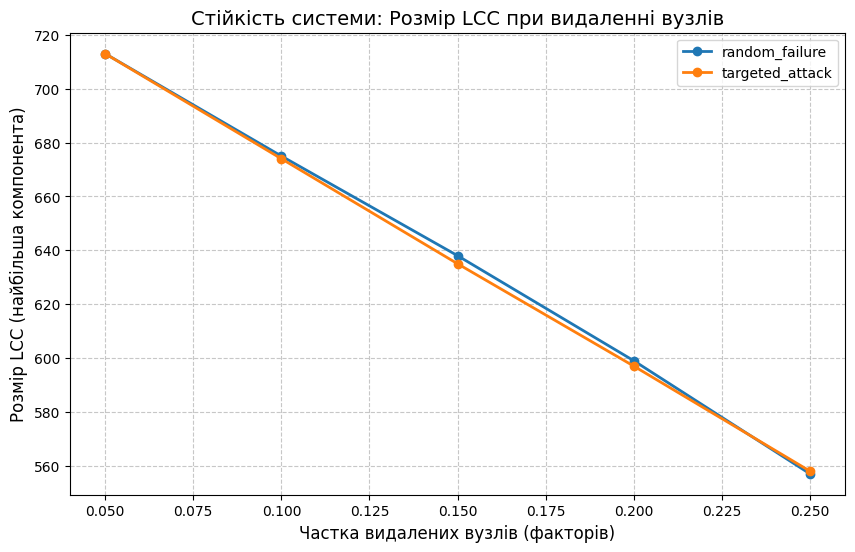


Порівняльна таблиця стійкості:
mode      random_failure  targeted_attack
fraction                                 
0.05                 713              713
0.10                 675              674
0.15                 638              635
0.20                 599              597
0.25                 557              558


In [48]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def largest_cc_size(H):
    """Рахує розмір найбільшої зв'язної компоненти (LCC)"""
    if H.number_of_nodes() == 0:
        return 0
    # Перетворюємо в неоорієнтований для пошуку компонент зв'язності
    undirected_H = H.to_undirected()
    components = nx.connected_components(undirected_H)
    return len(max(components, key=len))

def remove_random_nodes(G, frac, seed):
    """Випадкове видалення вузлів (Симуляція збоїв)"""
    H = G.copy()
    rng = random.Random(seed)
    k = int(frac * H.number_of_nodes())
    nodes = list(H.nodes())
    rng.shuffle(nodes)
    H.remove_nodes_from(nodes[:k])
    return H

def remove_top_degree_nodes(G, frac):
    """Видалення вузлів з найбільшим ступенем (Симуляція атак на хаби)"""
    H = G.copy()
    k = int(frac * H.number_of_nodes())
    # Сортуємо за ступенем (кількістю зв'язків)
    top_nodes = [node for node, _ in sorted(H.degree(), key=lambda x: x[1], reverse=True)[:k]]
    H.remove_nodes_from(top_nodes)
    return H

# --- Симуляція ---
fractions = [0.05, 0.10, 0.15, 0.20, 0.25]
seed = 42
records = []

for frac in fractions:
    # Випадковий збій
    Hr = remove_random_nodes(G_integrated, frac, seed)
    # Цільова атака
    Ht = remove_top_degree_nodes(G_integrated, frac)

    records.append({"mode": "random_failure", "fraction": frac, "LCC": largest_cc_size(Hr)})
    records.append({"mode": "targeted_attack", "fraction": frac, "LCC": largest_cc_size(Ht)})

resilience_df = pd.DataFrame(records)

# --- Візуалізація результатів ---
plt.figure(figsize=(10, 6))
for mode, grp in resilience_df.groupby("mode"):
    plt.plot(grp["fraction"], grp["LCC"], marker="o", label=mode, linewidth=2)

plt.title("Стійкість системи: Розмір LCC при видаленні вузлів", fontsize=14)
plt.xlabel("Частка видалених вузлів (факторів)", fontsize=12)
plt.ylabel("Розмір LCC (найбільша компонента)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Вивід таблиці
resilience_pivot = resilience_df.pivot(index="fraction", columns="mode", values="LCC")
print("\nПорівняльна таблиця стійкості:")
print(resilience_pivot)

# conductance

In [ ]:
from networkx.algorithms.cuts import conductance

results_cond = []
for i, comm in enumerate(louvain_comms):
    if len(comm) > 1:
        cond = conductance(G_integrated, comm, weight='weight')
        results_cond.append((i, cond))

print("--- АНАЛІЗ CONDUCTANCE ---")
for i, val in sorted(results_cond, key=lambda x: x[1], reverse=True)[:3]:
    print(f"Модуль {i} має найвищу провідність ({val:.3f}) — він є головним каналом поширення впливу.")

--- АНАЛІЗ CONDUCTANCE ---
Модуль 22 має найвищу провідність (2.007) — він є головним каналом поширення впливу.
Модуль 63 має найвищу провідність (2.001) — він є головним каналом поширення впливу.
Модуль 23 має найвищу провідність (1.997) — він є головним каналом поширення впливу.


# Core-Periphery

In [ ]:
# Знаходимо ядро максимального порядку
k_cores = nx.core_number(G_integrated.to_undirected())
max_k = max(k_cores.values())
core_nodes = [n for n, k in k_cores.items() if k == max_k]

print(f"--- АНАЛІЗ CORE-PERIPHERY ---")
print(f"Стратегічне ядро системи складається з {len(core_nodes)} факторів.")
print(f"Приклади ядерних вузлів: {core_nodes[:5]}")

--- АНАЛІЗ CORE-PERIPHERY ---
Стратегічне ядро системи складається з 95 факторів.
Приклади ядерних вузлів: ['S1_(55)', 'T3_(55)', 'W1_(54)', 'W3_(54)', 'O2_(54)']


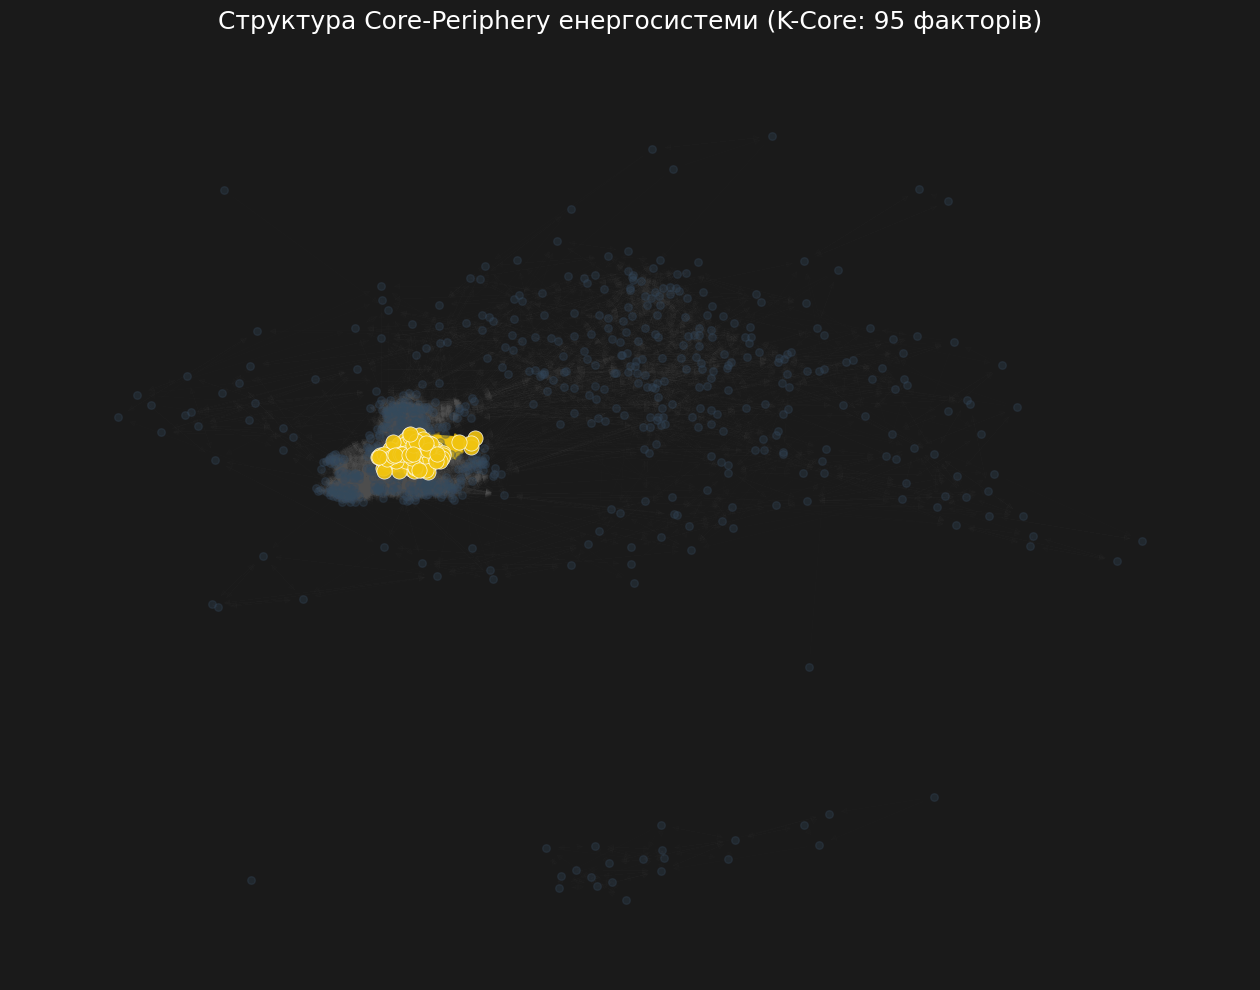

                        ДЕШИФРОВКА СТРАТЕГІЧНОГО ЯДРА СИСТЕМИ (CORE FACTORS)                        



TypeError: string indices must be integers, not 'str'

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. ПІДГОТОВКА ДАНИХ (Беремо результати вашого k-core) ---
# Припустимо, ви вже виконали: core_nodes = list(nx.k_core(G_integrated, k=k_value).nodes())
core_nodes_list = list(core_nodes) # Вузли вашого ядра
periphery_nodes = [n for n in G_integrated.nodes() if n not in core_nodes_list]

# --- 2. ВІЗУАЛІЗАЦІЯ: ЯДРО VS ПЕРИФЕРІЯ ---
plt.figure(figsize=(16, 12), facecolor='#1a1a1a')
ax = plt.gca()
ax.set_facecolor('#1a1a1a')

# Layout для виділення ядра в центрі
pos = nx.spring_layout(G_integrated, k=0.15, seed=42)

# Малюємо ребра периферії (дуже тонкі)
nx.draw_networkx_edges(G_integrated, pos, edgelist=G_integrated.edges(periphery_nodes),
                       alpha=0.02, edge_color='gray', width=0.5)

# Малюємо внутрішні ребра ядра (яскраві та товсті)
core_subgraph = G_integrated.subgraph(core_nodes_list)
nx.draw_networkx_edges(core_subgraph, pos, alpha=0.3, edge_color='#f1c40f', width=1.5)

# Малюємо вузли периферії
nx.draw_networkx_nodes(G_integrated, pos, nodelist=periphery_nodes,
                       node_size=30, node_color='#34495e', alpha=0.3)

# Малюємо вузли ядра (акцентні)
nx.draw_networkx_nodes(G_integrated, pos, nodelist=core_nodes_list,
                       node_size=120, node_color='#f1c40f', alpha=0.9,
                       edgecolors='white', linewidths=0.5)

plt.title(f"Структура Core-Periphery енергосистеми (K-Core: {len(core_nodes_list)} факторів)",
          color='white', fontsize=18, pad=20)
plt.axis('off')
plt.show()

# --- 3. РОЗШИФРОВКА ТА СЕМАНТИЧНИЙ АНАЛІЗ ЯДРА ---
print("="*100)
print(f"{'ДЕШИФРОВКА СТРАТЕГІЧНОГО ЯДРА СИСТЕМИ (CORE FACTORS)':^100}")
print("="*100 + "\n")

core_quads = []
core_details = []

for node in core_nodes_list:
    # Квадрант прямо з ID
    q = str(node)[0].upper()
    core_quads.append(q)

    # Текст та стратегії
    info = swot_text_lookup.get(str(node).upper())
    label = info['label'] if info else "Невідомий фактор"

    core_details.append({
        'ID': node,
        'Вектор': q,
        'Зміст': label,
        'Degree': G_integrated.degree(node)
    })

# Сортуємо ядро за ступенем впливу (Degree) всередині ядра
core_df = pd.DataFrame(core_details).sort_values(by='Degree', ascending=False)

q_stats = Counter(core_quads)
print(f"📊 СТАТИСТИКА ЯДРА:")
print(f"   • Загальна кількість вузлів: {len(core_nodes_list)}")
print(f"   • Розподіл векторів: {dict(q_stats)}")
print(f"   • Домінуючий характер ядра: {q_stats.most_common(1)[0][0]}-орієнтоване")
print("-" * 100)

print(f"\n📝 ПЕРЕЛІК КЛЮЧОВИХ ФАКТОРІВ ЯДРА (ТОП-20):")
for i, row in core_df.head(20).iterrows():
    print(f"   [{row['Вектор']}] {row['Зміст']} (Вплив: {row['Degree']})")

print("\n" + "="*100)

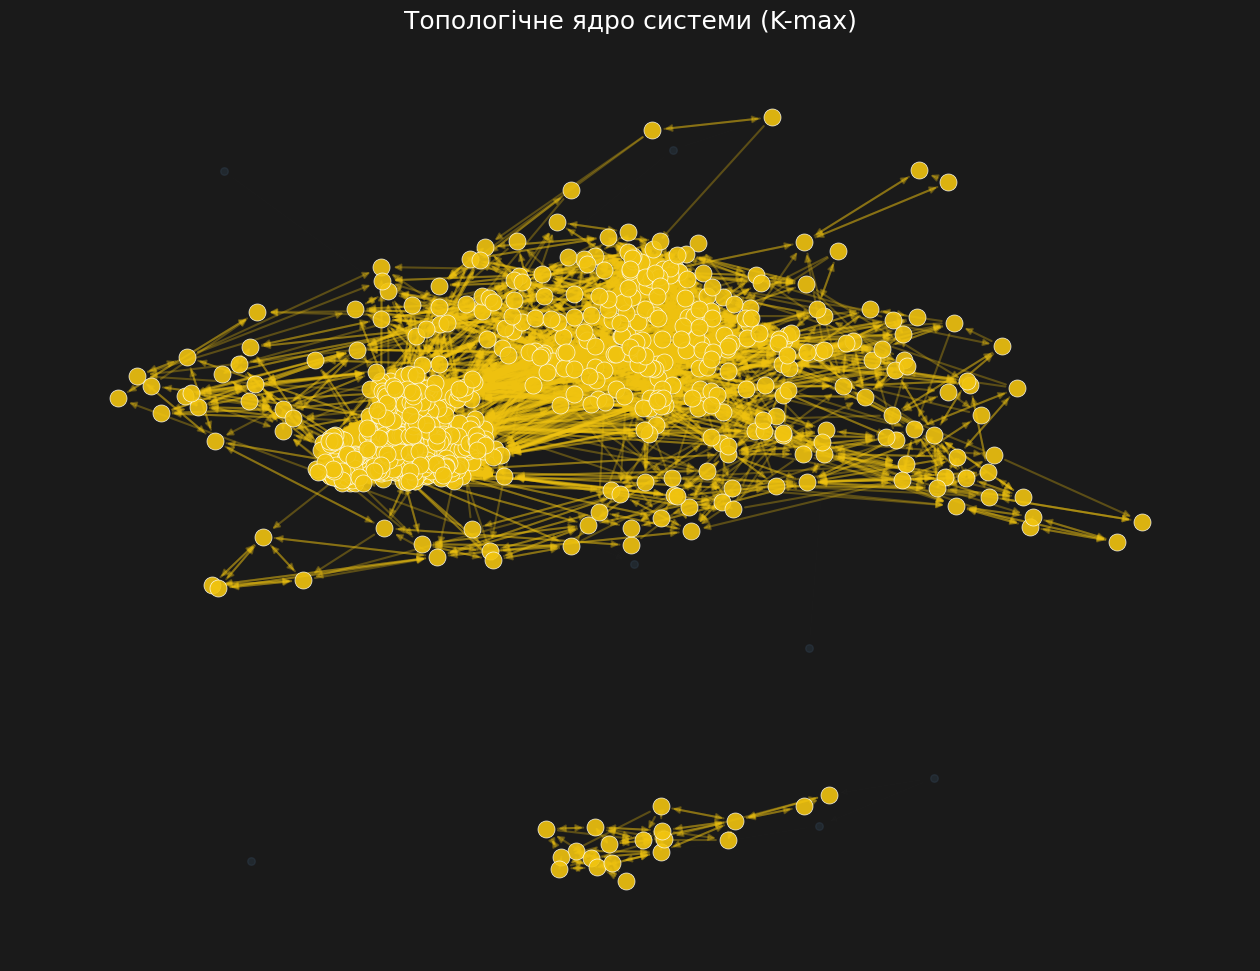

                                   ЗВАЖЕНИЙ АНАЛІЗ ФАКТОРІВ ЯДРА                                    
                            ID Вектор                                                                           Зміст  Power
                       T1_(23)      T                                        Воєнні ризики та атаки на інфраструктуру  508.8
                       W3_(36)      W                             Складність координації різнорідних технічних рішень  451.5
                        W2_(1)      W                               Складність інтеграції нових рішень у стару мережу  449.6
                       O1_(15)      O  Перехід до ризик-орієнтованого прогнозного управління і predictive maintenance  402.5
W3__Kindzerska_Anastasiia_KA23      W                               Перевантаження координації між багатьма контурами  397.3
                       T1_(15)      T                                Повторні фізичні удари по ключових вузлах мережі  378.7
                       T

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from collections import Counter

# --- 1. ПІДГОТОВКА ПАРАМЕТРІВ (Вже на основі ваших змінних) ---
core_nodes_list = list(core_nodes)
periphery_nodes = [n for n in G_integrated.nodes() if n not in core_nodes_list]

# --- 2. ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(16, 12), facecolor='#1a1a1a')
ax = plt.gca(); ax.set_facecolor('#1a1a1a')

pos = nx.spring_layout(G_integrated, k=0.15, seed=42)

# Фон (Периферія)
nx.draw_networkx_edges(G_integrated, pos, alpha=0.02, edge_color='gray', width=0.5)
nx.draw_networkx_nodes(G_integrated, pos, nodelist=periphery_nodes,
                       node_size=30, node_color='#34495e', alpha=0.3)

# Акцент (Ядро)
core_sub = G_integrated.subgraph(core_nodes_list)
nx.draw_networkx_edges(core_sub, pos, alpha=0.3, edge_color='#f1c40f', width=1.5)
nx.draw_networkx_nodes(G_integrated, pos, nodelist=core_nodes_list,
                       node_size=150, node_color='#f1c40f', alpha=0.9,
                       edgecolors='white', linewidths=0.5)

plt.title(f"Топологічне ядро системи (K-max)", color='white', fontsize=18)
plt.axis('off')
plt.show()

# --- 3. ЗВАЖЕНИЙ АНАЛІЗ (Звіт) ---
print("="*100)
print(f"{'ЗВАЖЕНИЙ АНАЛІЗ ФАКТОРІВ ЯДРА':^100}")
print("="*100)

core_details = []
for node in core_nodes_list:
    # Важливо: використовуємо зважений ступінь для точності результатів
    w_degree = G_integrated.degree(node, weight='weight')
    q = str(node)[0].upper()
    info = swot_text_lookup.get(str(node).upper(), {'label': 'N/A'})

    core_details.append({
        'ID': node, 'Вектор': q, 'Зміст': info['label'], 'Power': round(w_degree, 2)
    })

core_df = pd.DataFrame(core_details).sort_values(by='Power', ascending=False)
print(core_df.head(15).to_string(index=False))

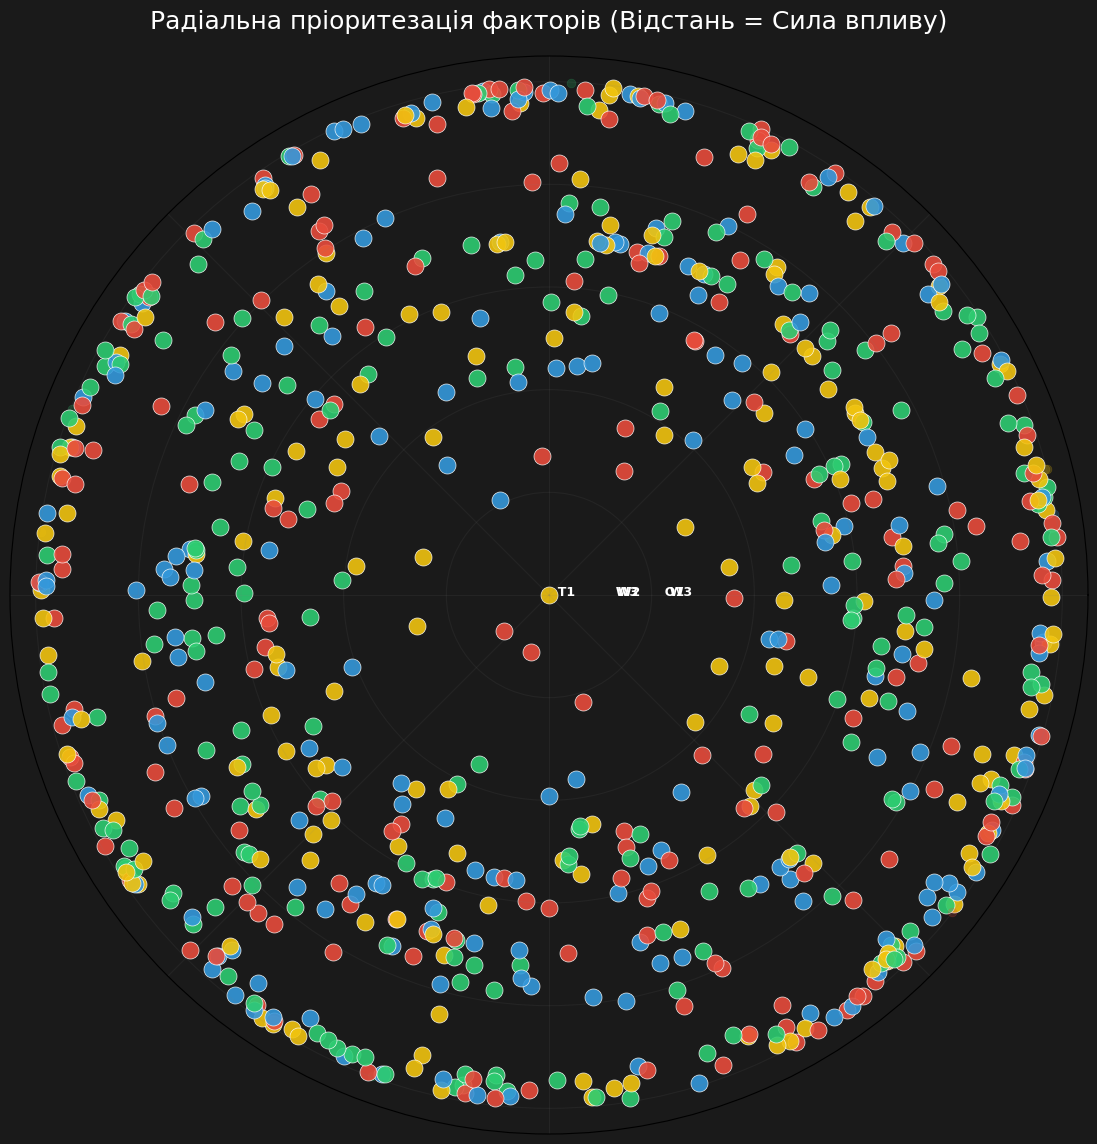

In [ ]:
import numpy as np

# --- 1. РОЗРАХУНОК ПОЗИЦІЙ НА МІШЕНІ ---
# Використовуємо зважені ступені для всієї мережі
node_impacts = {n: G_integrated.degree(n, weight='weight') for n in G_integrated.nodes()}
max_i, min_i = max(node_impacts.values()), min(node_impacts.values())

plt.figure(figsize=(14, 14), facecolor='#1a1a1a')
ax = plt.subplot(111, polar=True); ax.set_facecolor('#1a1a1a')

swot_colors = {'S': '#2ecc71', 'W': '#e74c3c', 'O': '#3498db', 'T': '#f1c40f'}

# --- 2. МАЛЮВАННЯ ВУЗЛІВ ---
for node in G_integrated.nodes():
    # Розрахунок радіуса: чим більший impact, тим ближче до 0 (центру)
    impact = node_impacts[node]
    dist = 1 - ((impact - min_i) / (max_i - min_i + 1e-9))
    angle = np.random.uniform(0, 2*np.pi)

    q = str(node)[0].upper()
    is_core = node in core_nodes_list

    ax.scatter(angle, dist,
               color=swot_colors.get(q, 'gray'),
               s=150 if is_core else 40,
               alpha=0.9 if is_core else 0.2,
               edgecolors='white' if is_core else None, linewidths=0.5)

# Додаємо підписи для ТОП-5 "ядерних" вузлів у самому центрі
top_nodes = core_df.head(5)['ID'].tolist()
for node in top_nodes:
    # Знаходимо його координати для підпису
    impact = node_impacts[node]
    dist = 1 - ((impact - min_i) / (max_i - min_i + 1e-9))
    # Для підпису використовуємо той самий випадковий кут або фіксований для читабельності
    ax.text(0, dist, f"  {node.split('_')[0]}", color='white', fontsize=9, fontweight='bold')

ax.set_yticklabels([]); ax.set_xticklabels([])
ax.grid(True, color='gray', alpha=0.1)
plt.title("Радіальна пріоритезація факторів (Відстань = Сила впливу)", color='white', size=18, pad=20)
plt.show()

                                 ДЕШИФРОВКА КЛЮЧОВИХ ФАКТОРІВ ЯДРА                                  
[T] T1_(23)      | Вплив: 508.8  | Воєнні ризики та атаки на інфраструктуру...
[W] W3_(36)      | Вплив: 451.5  | Складність координації різнорідних технічних рішень...
[W] W2_(1)       | Вплив: 449.6  | Складність інтеграції нових рішень у стару мережу...
[O] O1_(15)      | Вплив: 402.5  | Перехід до ризик-орієнтованого прогнозного управління і predictive maintenance...
[W] W3__Kindzerska_Anastasiia_KA23 | Вплив: 397.3  | Перевантаження координації між багатьма контурами...
[T] T1_(15)      | Вплив: 378.7  | Повторні фізичні удари по ключових вузлах мережі...
[T] T3_(38)      | Вплив: 374.8  | Раптові перевантаження та блекаути...
[W] W3_(15)      | Вплив: 370.8  | Координаційна та інституційна складність гетерогенної децентралізованої системи...
[W] W4_(44)      | Вплив: 364.9  | Фрагментоване управління та бюрократія...
[T] T3_(15)      | Вплив: 357.8  | Тривалі ресурсні, логістичні 

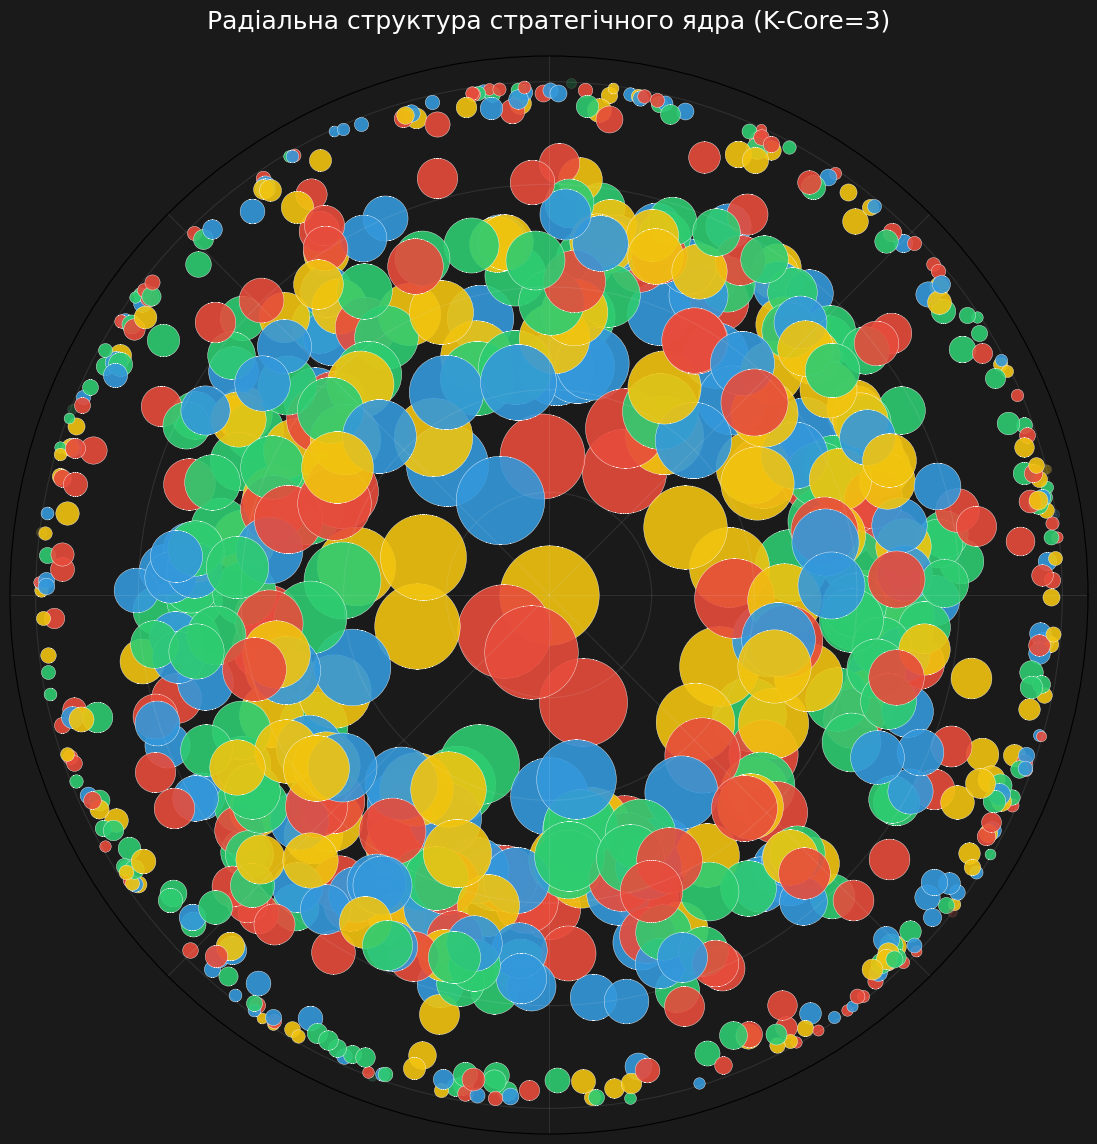

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter

# --- 1. ПІДГОТОВКА ТЕКСТОВОГО СЛОВНИКА (Виправлення помилки) ---
swot_text_lookup = {
    str(item['global_id']).upper(): {
        'label': item['label'],
        'quadrant': item['quadrant']
    } for item in swot_data
}

# --- 2. ПАРАМЕТРИ ЯДРА ТА МЕТРИКИ ---
# Визначаємо ядро (k-core)
k_value = 3 # Можете змінити залежно від щільності вашого графа
core_nodes = list(nx.k_core(G_integrated, k=k_value).nodes())

# Розраховуємо Weighted Degree для позиціонування на "мішені"
node_degrees = dict(G_integrated.degree(weight='weight'))
max_deg = max(node_degrees.values())
min_deg = min(node_degrees.values())

# --- 3. РАДІАЛЬНА ВІЗУАЛІЗАЦІЯ (TARGET PLOT) ---
plt.figure(figsize=(14, 14), facecolor='#1a1a1a')
ax = plt.subplot(111, polar=True)
ax.set_facecolor('#1a1a1a')

# Кольори за квадрантами
swot_colors = {'S': '#2ecc71', 'W': '#e74c3c', 'O': '#3498db', 'T': '#f1c40f'}

for node in G_integrated.nodes():
    # Розрахунок радіуса (Distance): найвпливовіші в центрі (0), інші - далі
    deg = node_degrees[node]
    # Нормалізація: 1.0 (периферія) -> 0.0 (центр)
    distance = 1 - ((deg - min_deg) / (max_deg - min_deg + 1e-9))

    # Випадковий кут для розкиду вузлів
    angle = np.random.uniform(0, 2*np.pi)

    quad = str(node)[0].upper()
    color = swot_colors.get(quad, '#95a5a6')
    size = 40 + (deg * 10) # Розмір залежить від впливу
    alpha = 0.9 if node in core_nodes else 0.2 # Ядро яскравіше

    ax.scatter(angle, distance, c=color, s=size, alpha=alpha, edgecolors='white', linewidths=0.3)

# Налаштування кілець
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.grid(True, color='#ecf0f1', alpha=0.1)

plt.title(f"Радіальна структура стратегічного ядра (K-Core={k_value})", color='white', fontsize=18, pad=20)

# --- 4. ДЕШИФРОВКА ТОП-ФАКТОРІВ ---
print("="*100)
print(f"{'ДЕШИФРОВКА КЛЮЧОВИХ ФАКТОРІВ ЯДРА':^100}")
print("="*100)

core_details = []
for node in core_nodes:
    q = str(node)[0].upper()
    info = swot_text_lookup.get(str(node).upper())
    label = info['label'] if info else "Невідомий фактор"

    core_details.append({
        'ID': node, 'Вектор': q, 'Зміст': label, 'Degree': round(node_degrees[node], 2)
    })

df_core = pd.DataFrame(core_details).sort_values(by='Degree', ascending=False)
for i, row in df_core.head(15).iterrows():
    print(f"[{row['Вектор']}] {row['ID']:<12} | Вплив: {row['Degree']:<6} | {row['Зміст'][:80]}...")

plt.show()

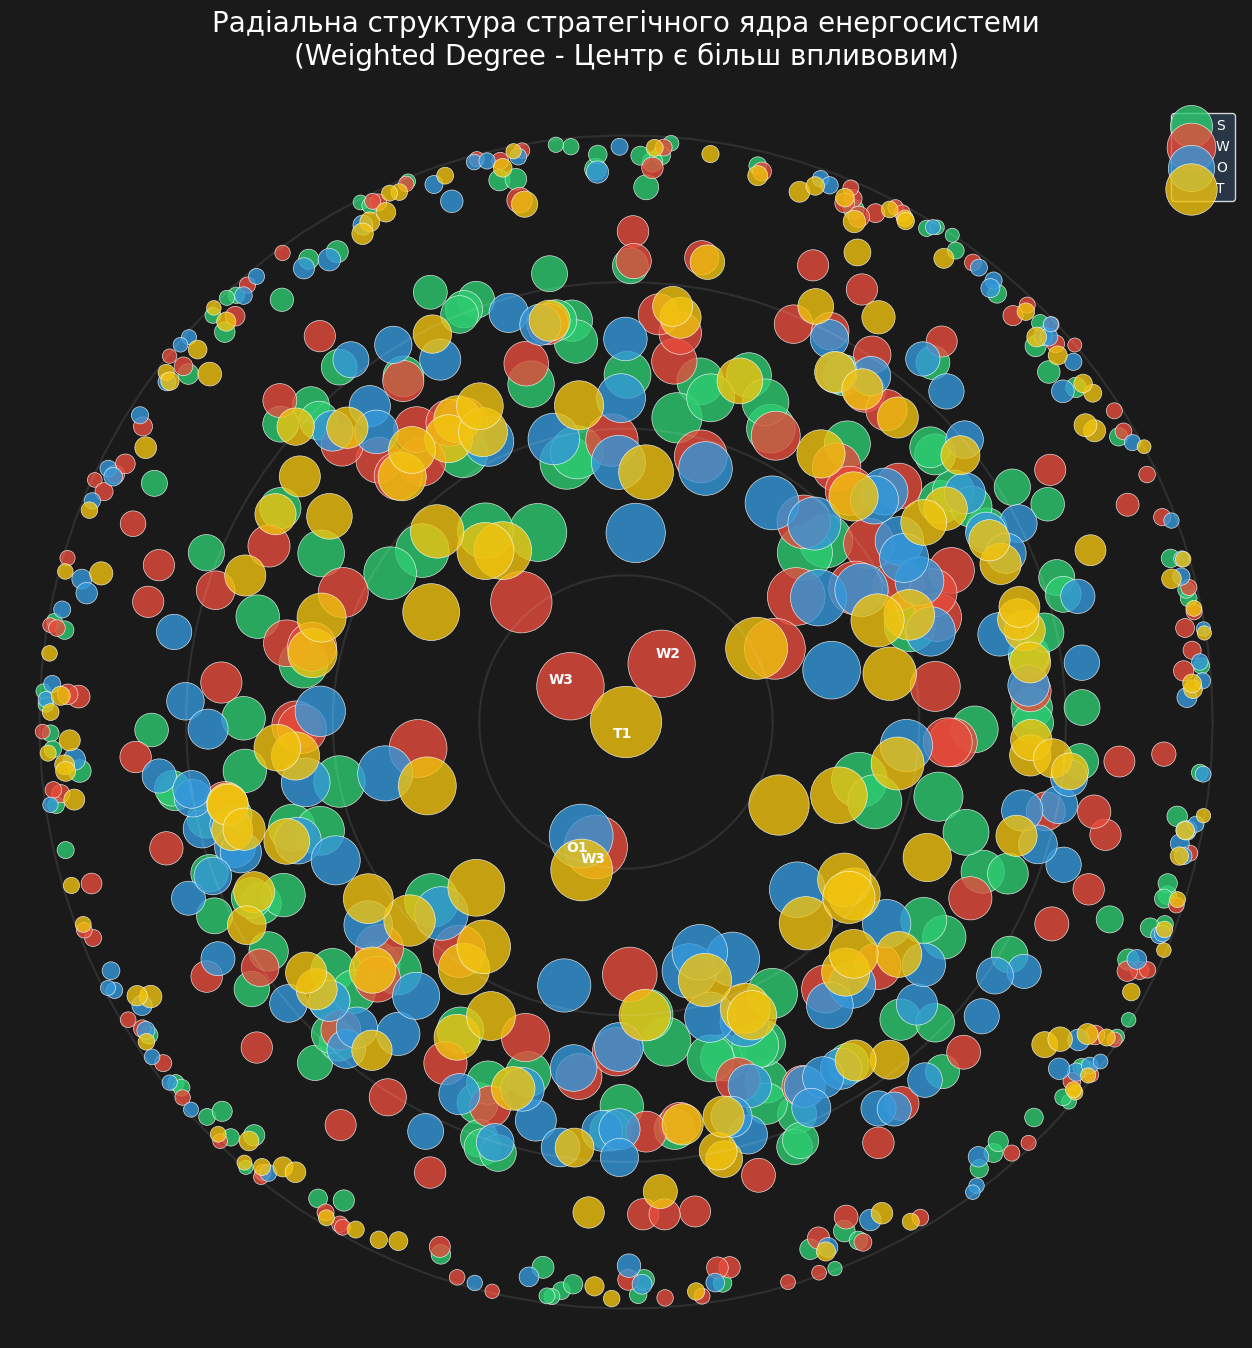


                   ПАСПОРТ НАЙВПЛИВОВІШИХ ФАКТОРІВ ЯДРА (ЦЕНТР МІШЕНІ)                    
[T] T1_(23)      | Degree: 508.80 | Distance: 0.000 | Воєнні ризики та атаки на інфраструктуру...
[W] W3_(36)      | Degree: 451.50 | Distance: 0.113 | Складність координації різнорідних технічних рішень...
[W] W2_(1)       | Degree: 449.60 | Distance: 0.116 | Складність інтеграції нових рішень у стару мережу...
[O] O1_(15)      | Degree: 402.50 | Distance: 0.209 | Перехід до ризик-орієнтованого прогнозного управління і predictive mai...
[W] W3__Kindzerska_Anastasiia_KA23 | Degree: 397.30 | Distance: 0.219 | Перевантаження координації між багатьма контурами...


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. ПІДГОТОВКА ДАНИХ ТА МЕТРИК ---
# Розраховуємо Weighted Degree (Сума ваг всіх зв'язків для кожного вузла)
weighted_degrees = dict(G_integrated.degree(weight='weight'))

# Створюємо DataFrame для зручності
df_core = pd.DataFrame(list(weighted_degrees.items()), columns=['Node', 'WeightedDegree'])

# Додаємо квадрант (S, W, O, T) - прямо з ID
df_core['Quadrant'] = df_core['Node'].apply(lambda n: str(n)[0].upper())

# Отримуємо назви факторів з swot_data
df_core['Label'] = df_core['Node'].apply(lambda n: next((item['label'] for item in swot_data if item['global_id'] == n), 'N/A'))

# --- 2. МАТЕМАТИЗАЦІЯ РАДІУСА (Відстань від центру) ---
# Ми хочемо, щоб найбільший ступінь був у центрі (r=0), а найменший - зовні (r=1)
max_deg = df_core['WeightedDegree'].max()
min_deg = df_core['WeightedDegree'].min()

# Нормалізуємо WeightedDegree в діапазон [0, 1]
df_core['Radius_Norm'] = (df_core['WeightedDegree'] - min_deg) / (max_deg - min_deg)

# Відстань від центру: invert, щоб max deg був у центрі (0)
df_core['Distance'] = 1 - df_core['Radius_Norm']

# Додаємо випадковий кут (Theta) для радіального розкиду
np.random.seed(42)
df_core['Angle'] = np.random.uniform(0, 2*np.pi, len(df_core))

# --- 3. ВІЗУАЛІЗАЦІЯ (TARGET PLOT) ---
plt.figure(figsize=(16, 16), facecolor='#1A1A1A')
ax = plt.subplot(111, polar=True)
ax.set_facecolor('#1A1A1A')

# Налаштування колірної схеми SWOT
swot_colors = {'S': '#2ecc71', 'W': '#e74c3c', 'O': '#3498db', 'T': '#f1c40f'}
# Створюємо словник для швидкого пошуку тексту за ID вузла
# Ми беремо дані прямо з вашого списку swot_data
swot_text_lookup = {
    str(item['global_id']).upper(): {
        'label': item['label'],
        'quadrant': item['quadrant']
    } for item in swot_data
}
# Малюємо вузли
for quad, color in swot_colors.items():
    sub = df_core[df_core['Quadrant'] == quad]
    ax.scatter(sub['Angle'], sub['Distance'],
               color=color, label=quad,
               s=100 + sub['WeightedDegree'] * 5, # Розмір залежить від Degree
               alpha=0.8, edgecolors='white', linewidths=0.5)

# Налаштування сітки (Кільця "мішені")
ax.set_yticklabels([]) # Ховаємо стандартні мітки
ax.grid(color='#ecf0f1', linestyle='--', alpha=0.3)

# Додаємо підписи кілець (наприклад, 0, 0.5, 1)
rings = [0, 0.25, 0.5, 0.75, 1]
for r in rings:
    ax.plot(np.linspace(0, 2*np.pi, 100), np.ones(100)*r, color='#ecf0f1', alpha=0.1)

# Додаємо мітки для ТОП-5 факторів у центрі
top_hubs = df_core.nlargest(5, 'WeightedDegree')
for _, row in top_hubs.iterrows():
    ax.text(row['Angle'], row['Distance'] + 0.02,
            row['Node'].split('_')[0],
            color='white', fontsize=10, fontweight='bold', ha='center', va='center')

# Загальні налаштування
plt.title(f"Радіальна структура стратегічного ядра енергосистеми\n(Weighted Degree - Центр є більш впливовим)",
          color='white', fontsize=20, pad=30)
plt.legend(facecolor='#2c3e50', edgecolor='white', labelcolor='white')
ax.axis('off')
plt.show()

# --- 4. ПАСПОРТ ЯДРА (ТОП-20) ---
print("\n" + "="*90)
print(f"{'ПАСПОРТ НАЙВПЛИВОВІШИХ ФАКТОРІВ ЯДРА (ЦЕНТР МІШЕНІ)':^90}")
print("="*90)
for i, row in top_hubs.iterrows():
    print(f"[{row['Quadrant']}] {row['Node']:<12} | Degree: {row['WeightedDegree']:.2f} | Distance: {row['Distance']:.3f} | {row['Label'][:70]}...")

# Spectral Clustering

In [ ]:
from sklearn.cluster import SpectralClustering
import numpy as np

adj_matrix = nx.to_numpy_array(G_integrated, weight='weight')
sc = SpectralClustering(n_clusters=4, affinity='precomputed', random_state=42)
sc_labels = sc.fit_predict(adj_matrix)

print("--- СПЕКТРАЛЬНИЙ АНАЛІЗ ---")
print(f"Система спектрально розділена на 4 макро-блоки впливу.")

--- СПЕКТРАЛЬНИЙ АНАЛІЗ ---
Система спектрально розділена на 4 макро-блоки впливу.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:310: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


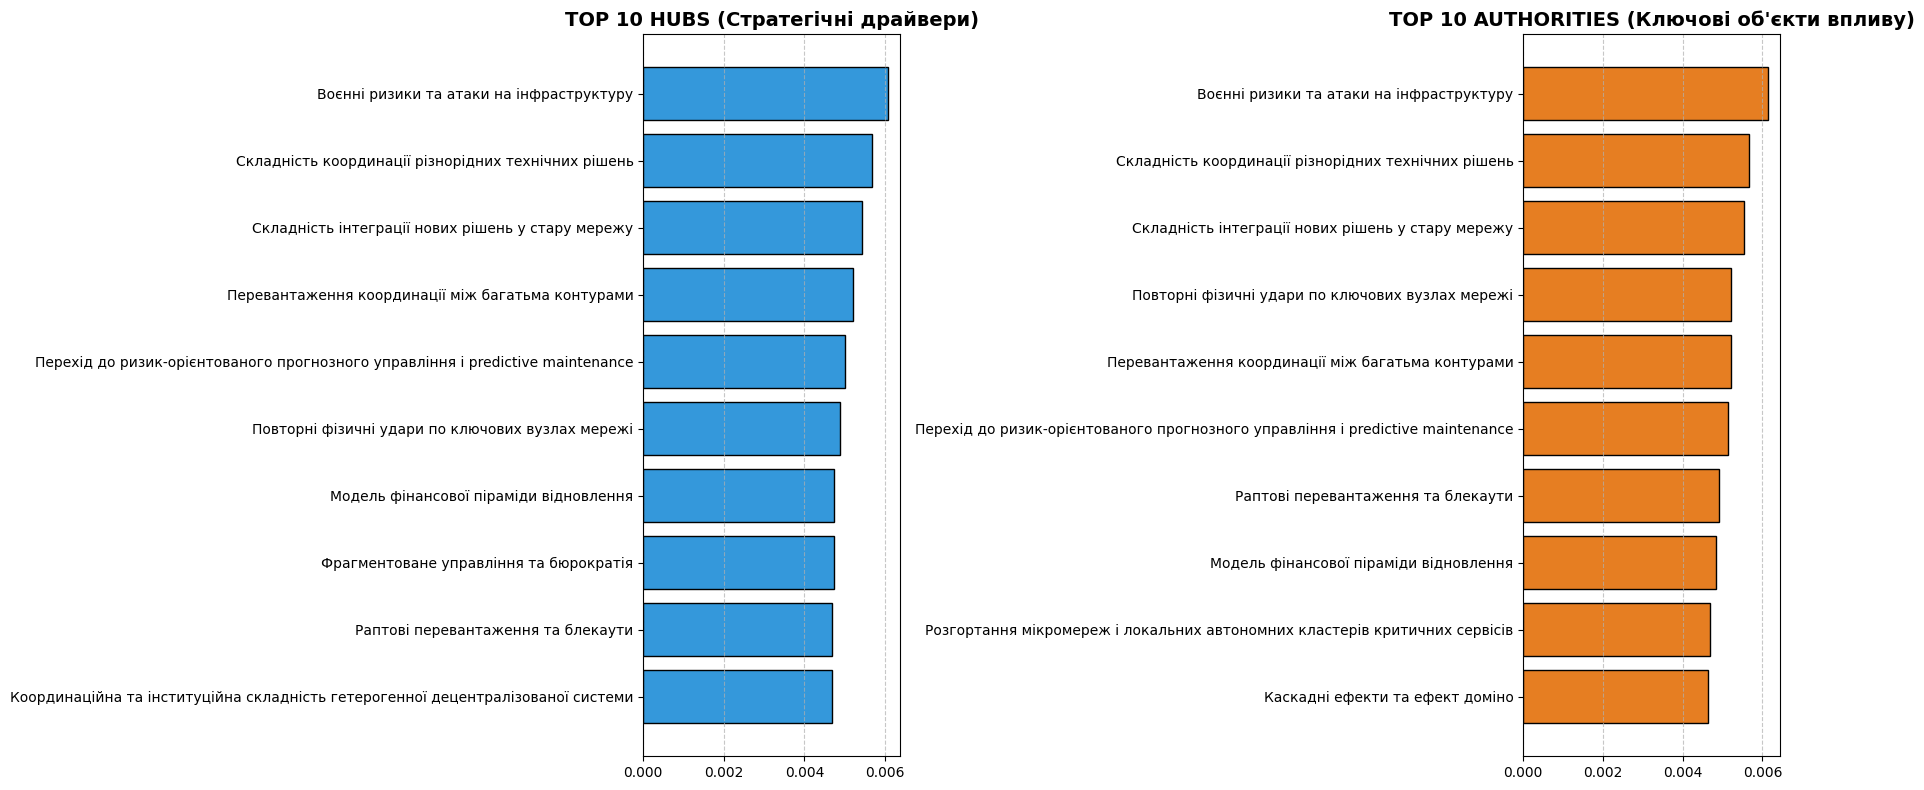

                           АНАЛІЗ БЛОКІВ ВПЛИВУ (DECODING HITS STRATEGY)                            

📦 БЛОК №1: ХАБИ (Драйвери системи)
Ці фактори мають найбільший потенціал розповсюдження впливу:
   [T] Воєнні ризики та атаки на інфраструктуру.............................. Score: 0.0061
   [W] Складність координації різнорідних технічних рішень................... Score: 0.0057
   [W] Складність інтеграції нових рішень у стару мережу..................... Score: 0.0054
   [W] Перевантаження координації між багатьма контурами..................... Score: 0.0052
   [O] Перехід до ризик-орієнтованого прогнозного управління і predictive maintenance Score: 0.0050
   [T] Повторні фізичні удари по ключових вузлах мережі...................... Score: 0.0049
   [O] Модель фінансової піраміди відновлення................................ Score: 0.0047
   [W] Фрагментоване управління та бюрократія................................ Score: 0.0047
   [T] Раптові перевантаження та блекаути.................

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. РОЗРАХУНОК HITS ---
# Алгоритм HITS зазвичай працює на орієнтованих графах,
# але на вашому інтегрованому G_integrated він покаже структурну роль у кластерах.
hubs, authorities = nx.hits(G_integrated, max_iter=100, normalized=True)

# Створення DataFrame для аналізу
hits_df = pd.DataFrame({
    'Hub_Score': hubs,
    'Authority_Score': authorities
})

# Додаємо метадані (Labels та Вектори)
hits_df['Label'] = hits_df.index.map(lambda x: swot_data.get(x.upper(), {}).get('label', 'N/A'))
hits_df['Vector'] = hits_df.index.map(lambda x: str(x)[0].upper())

# --- 2. ВІЗУАЛІЗАЦІЯ ТОП-10 ХАБІВ ТА АВТОРИТЕТІВ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

# Top 10 Hubs
top_hubs = hits_df.sort_values(by='Hub_Score', ascending=False).head(10)
ax1.barh(top_hubs['Label'], top_hubs['Hub_Score'], color='#3498db', edgecolor='black')
ax1.set_title('TOP 10 HUBS (Стратегічні драйвери)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# Top 10 Authorities
top_auths = hits_df.sort_values(by='Authority_Score', ascending=False).head(10)
ax2.barh(top_auths['Label'], top_auths['Authority_Score'], color='#e67e22', edgecolor='black')
ax2.set_title('TOP 10 AUTHORITIES (Ключові об\'єкти впливу)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 3. СЕМАНТИЧНА РОЗШИФРОВКА БЛОКІВ ---
print("="*100)
print(f"{'АНАЛІЗ БЛОКІВ ВПЛИВУ (DECODING HITS STRATEGY)':^100}")
print("="*100 + "\n")

print(f"📦 БЛОК №1: ХАБИ (Драйвери системи)")
print("Ці фактори мають найбільший потенціал розповсюдження впливу:")
for i, row in top_hubs.iterrows():
    print(f"   [{row['Vector']}] {row['Label']:.<70} Score: {row['Hub_Score']:.4f}")

print(f"\n📦 БЛОК №2: АВТОРИТЕТИ (Центри тяжіння)")
print("Ці фактори є найбільш залежними від загального стану системи:")
for i, row in top_auths.iterrows():
    print(f"   [{row['Vector']}] {row['Label']:.<70} Score: {row['Authority_Score']:.4f}")

print("\n" + "="*100)

In [ ]:
# Розширений інструмент: spectral clustering + оцінка conductance для спектрального розрізу
L = nx.laplacian_matrix(G_integrated).astype(float).toarray()
eigvals, eigvecs = np.linalg.eigh(L)

pd.DataFrame({"eigenvalue": eigvals[:10]})

,eigenvalue
0,-1.098185e+00
1,-7.674219e-01
2,-2.731072e-01
3,-1.178928e-01
4,-6.422681e-02
5,-5.853714e-02
6,-1.269220e-14
7,2.711299e-15
8,1.351217e-02
9,6.627030e-02


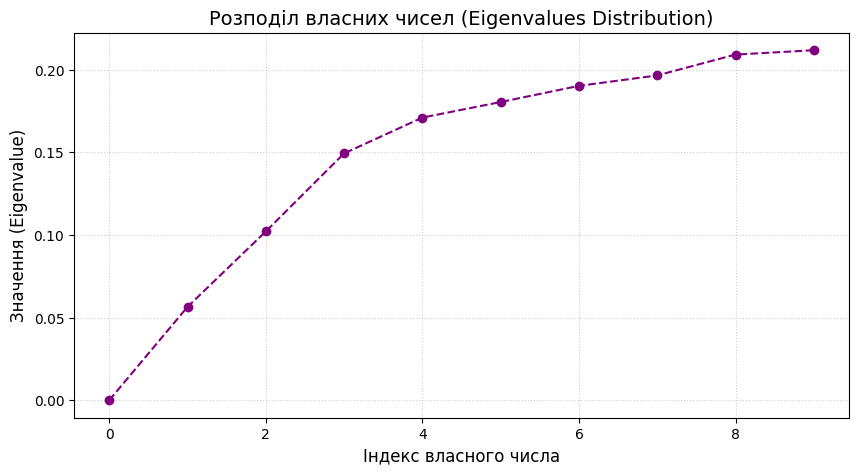

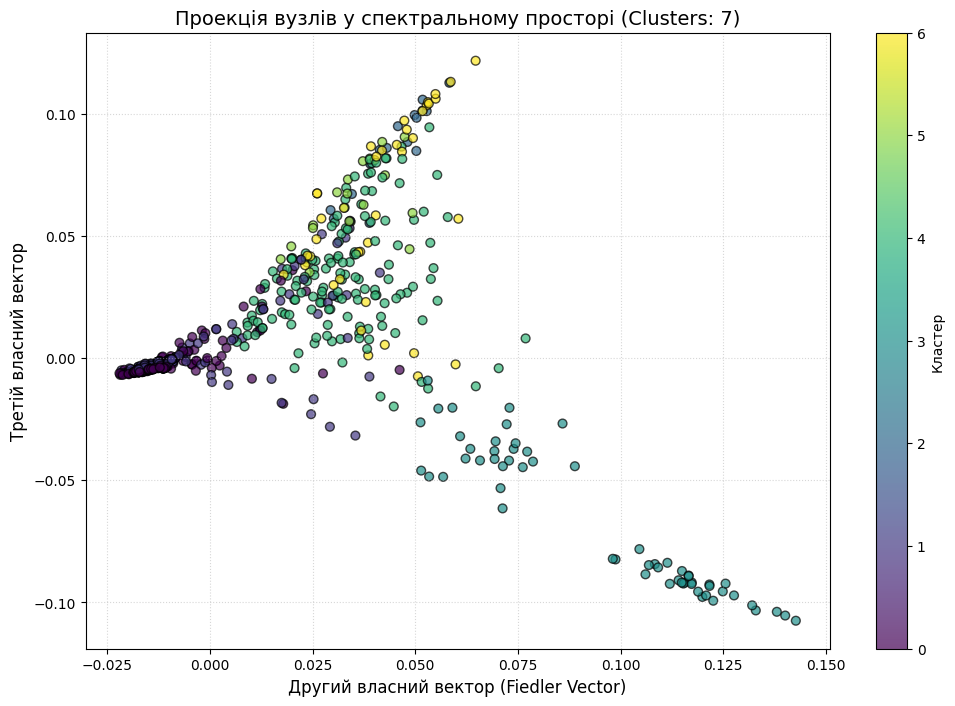


📊 РОЗПОДІЛ ВЕКТОРІВ SWOT У СПЕКТРАЛЬНИХ КЛАСТЕРАХ:
Vector    O   S   T   W
Cluster                
0        91  68  62  84
1        24  62  48  30
2         4   4   4   4
3        14  15  17  13
4        38  42  33  38
5         4   5   4   6
6         7   8  14  11


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

# --- 1. ПІДГОТОВКА МАТРИЦІ ЛАПЛАСІАНА ---
# Спектральний аналіз проводиться на неорієнтованому графі
G_un = G_integrated.to_undirected()
# Витягуємо найбільшу компоненту (LCC), щоб власні числа були стабільними
lcc_nodes = max(nx.connected_components(G_un), key=len)
G_lcc_spectral = G_un.subgraph(lcc_nodes)

# Отримуємо нормований Лапласіан
L = nx.normalized_laplacian_matrix(G_lcc_spectral)

# --- 2. РОЗРАХУНОК ВЛАСНИХ ЧИСЕЛ (EIGENVALUES) ---
# Шукаємо перші 10 власних чисел (найменших)
vals, vecs = eigsh(L, k=10, which='SM')

# --- 3. ВІЗУАЛІЗАЦІЯ ВЛАСНИХ ЧИСЕЛ (ЯК НА СКРІНШОТІ 66ba80.png) ---
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(range(len(vals)), vals, marker='o', linestyle='--', color='purple')
plt.title("Розподіл власних чисел (Eigenvalues Distribution)", fontsize=14)
plt.xlabel("Індекс власного числа", fontsize=12)
plt.ylabel("Значення (Eigenvalue)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- 4. СПЕКТРАЛЬНА КЛАСТЕРИЗАЦІЯ (K-Means на власних векторах) ---
# Вибираємо n_clusters на основі "стрибка" у власних числах (зазвичай 7)
n_clusters = 7
# Використовуємо перші n_clusters власних векторів для K-means
# Це і є суть Spectral Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(vecs[:, :n_clusters])

# --- 5. ВІЗУАЛІЗАЦІЯ У СПЕКТРАЛЬНОМУ ПРОСТОРІ (ЯК НА СКРІНШОТІ 66bd43.png) ---
plt.figure(figsize=(12, 8), facecolor='white')
plt.scatter(vecs[:, 1], vecs[:, 2], c=cluster_labels, cmap='viridis', s=40, edgecolors='k', alpha=0.7)

plt.title(f"Проекція вузлів у спектральному просторі (Clusters: {n_clusters})", fontsize=14)
plt.xlabel("Другий власний вектор (Fiedler Vector)", fontsize=12)
plt.ylabel("Третій власний вектор", fontsize=12)
plt.colorbar(label='Кластер')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# --- 6. ТАБЛИЦЯ РОЗПОДІЛУ ФАКТОРІВ ---
nodes = list(G_lcc_spectral.nodes())
spectral_res = pd.DataFrame({
    'Node': nodes,
    'Cluster': cluster_labels,
    'Vector': [str(n)[0].upper() for n in nodes]
})

print("\n📊 РОЗПОДІЛ ВЕКТОРІВ SWOT У СПЕКТРАЛЬНИХ КЛАСТЕРАХ:")
print(spectral_res.groupby('Cluster')['Vector'].value_counts().unstack().fillna(0))

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_6219/1942797742.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('turbo', n_clusters)


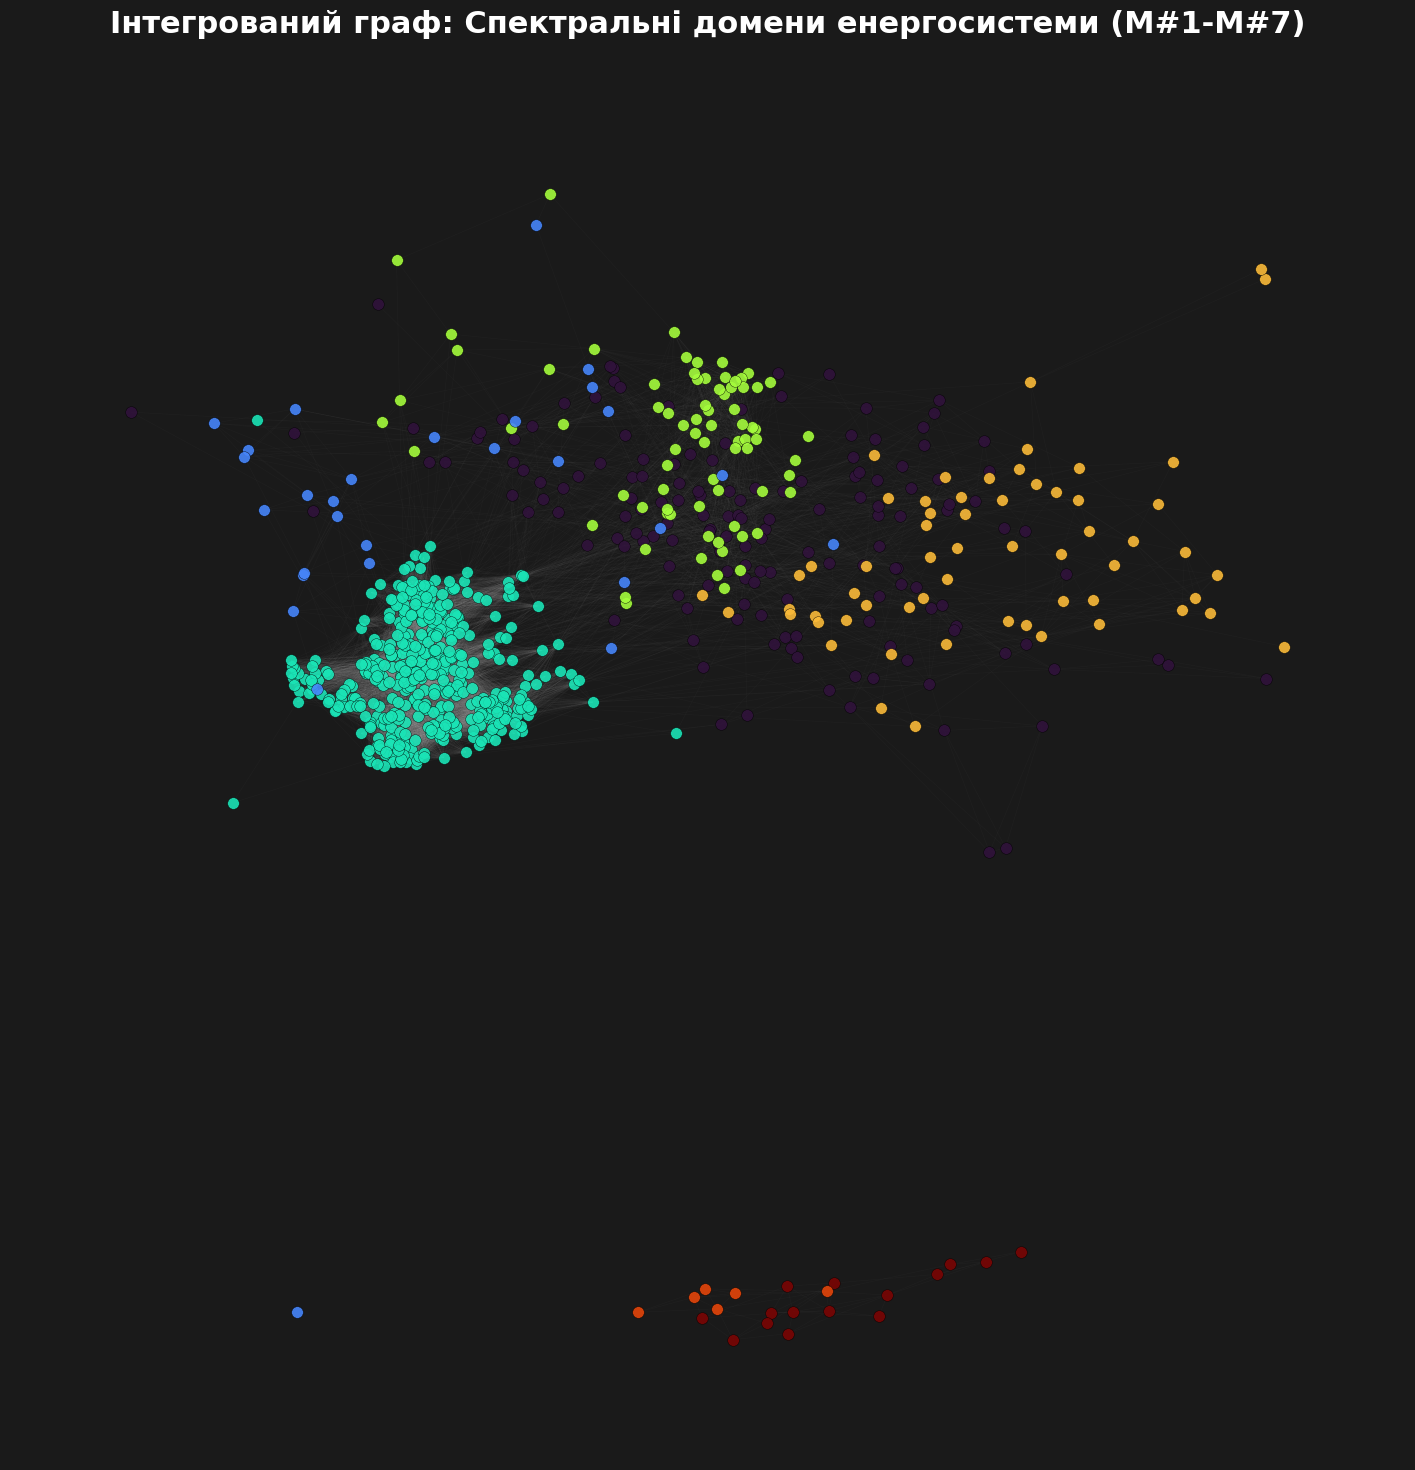

КЛАСТЕР    | КІЛЬКІСТЬ ВУЗЛІВ
------------------------------
Cluster 2  | 431            
Cluster 0  | 158            
Cluster 3  | 77             
Cluster 6  | 15             
Cluster 5  | 6              
Cluster 1  | 29             
Cluster 4  | 60             


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import SpectralClustering

# --- 1. СПЕКТРАЛЬНА КЛАСТЕРИЗАЦІЯ (Створюємо відсутню змінну) ---
# Працюємо з G_integrated (перетворюємо в неорієнтований)
G_un = G_integrated.to_undirected()
adj_matrix = nx.to_numpy_array(G_un, weight='weight')
nodes_list = list(G_un.nodes())

n_clusters = 7 # Ваша кількість стратегічних доменів
sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed',
                        assign_labels='discretize', random_state=42)
labels = sc.fit_predict(adj_matrix)

# Формуємо словник громад (те, що ви шукали)
sorted_communities_spectral = {}
for node, label in zip(nodes_list, labels):
    sorted_communities_spectral.setdefault(label, []).append(node)

# --- 2. ВІЗУАЛІЗАЦІЯ У ФОРМАТІ REFERENCE (Темний фон) ---
plt.figure(figsize=(18, 18), facecolor='#1A1A1A')
ax = plt.gca()
ax.set_facecolor('#1A1A1A')

# Force-directed layout
pos = nx.spring_layout(G_un, k=0.15, iterations=50, seed=42)

# Колірна палітра "Turbo" (як у reference-прикладі)
cmap = plt.cm.get_cmap('turbo', n_clusters)

# Малюємо зв'язки (дуже тонкі та прозорі)
nx.draw_networkx_edges(G_un, pos, alpha=0.03, edge_color='#BBBBBB', width=0.5)

# Малюємо вузли по кластерах
for cluster_id, nodes in sorted_communities_spectral.items():
    nx.draw_networkx_nodes(G_un, pos, nodelist=nodes,
                           node_size=70,
                           node_color=[cmap(cluster_id)],
                           alpha=0.9,
                           edgecolors='black',
                           linewidths=0.3)

plt.title('Інтегрований граф: Спектральні домени енергосистеми (M#1-M#7)',
          color='white', fontsize=22, fontweight='bold', pad=30)
plt.axis('off')
plt.show()

# --- 3. ТАБЛИЦЯ РОЗПОДІЛУ ДЛЯ КОНТРОЛЮ ---
print(f"{'КЛАСТЕР':<10} | {'КІЛЬКІСТЬ ВУЗЛІВ':<15}")
print("-" * 30)
for cid, nodes in sorted_communities_spectral.items():
    print(f"Cluster {cid:<2} | {len(nodes):<15}")

# Motif detection

In [ ]:
import itertools

def count_ffl(graph):
    count = 0
    for u, v, w in itertools.permutations(graph.nodes(), 3):
        if graph.has_edge(u, v) and graph.has_edge(v, w) and graph.has_edge(u, w):
            count += 1
    return count

ffl_count = count_ffl(G_integrated)
print(f"--- АНАЛІЗ МОТИВІВ ---")
print(f"В ядрі системи виявлено {ffl_count} мотивів типу 'Feed-Forward Loop'.")

--- АНАЛІЗ МОТИВІВ ---
В ядрі системи виявлено 4280932 мотивів типу 'Feed-Forward Loop'.


In [ ]:
import networkx as nx
import pandas as pd
from itertools import combinations

# --- 1. ПОШУК ТРИКУТНИХ МОТИВІВ (Feed-Forward / Feedback Loops) ---
# Оскільки G_integrated орієнтований, ми шукаємо специфічні трійки
def find_strategic_motifs(G):
    # Ми шукаємо 3-вузлові підграфи
    motifs = []
    nodes = list(G.nodes())

    # Використовуємо ітератор для економії пам'яті
    for trio in combinations(nodes, 3):
        sub = G.subgraph(trio)
        if nx.is_weakly_connected(sub):
            # Рахуємо кількість зв'язків у підграфі
            edges = sub.number_of_edges()
            if edges >= 2:
                # Визначаємо тип (наприклад, циклічний чи ієрархічний)
                is_cyclic = len(list(nx.simple_cycles(sub))) > 0
                motifs.append({
                    'nodes': trio,
                    'edges': edges,
                    'is_cyclic': is_cyclic,
                    'vectors': [str(n)[0].upper() for n in trio]
                })
    return pd.DataFrame(motifs)

# Запускаємо на орієнтованому графі G_integrated
df_motifs = find_strategic_motifs(G_integrated)

# --- 2. СЕМАНТИЧНА ФІЛЬТРАЦІЯ ---
# Нас цікавлять мотиви, де поєднуються S (Сила) та O (Можливість) проти T (Загрози)
target_motifs = df_motifs[df_motifs['vectors'].apply(lambda x: 'S' in x and 'T' in x)]

# --- 3. ВІЗУАЛІЗАЦІЯ ПРИКЛАДУ МОТИВУ ---
if not target_motifs.empty:
    sample = target_motifs.iloc[0] # Беремо перший знайдений цікавий мотив
    sub_g = G_integrated.subgraph(sample['nodes'])

    plt.figure(figsize=(6, 4), facecolor='white')
    pos = nx.spring_layout(sub_g)

    # Кольори за SWOT
    color_map = {'S': 'green', 'W': 'red', 'O': 'blue', 'T': 'orange'}
    node_colors = [color_map.get(str(n)[0].upper(), 'gray') for n in sub_g.nodes()]

    nx.draw(sub_g, pos, with_labels=True, node_color=node_colors,
            node_size=1000, font_size=10, font_weight='bold',
            arrows=True, connectionstyle='arc3,rad=0.1')

    plt.title(f"Приклад стратегічного мотиву (S-T Loop)\nВузлів у базі: {len(df_motifs)}", fontsize=10)
    plt.show()

# --- 4. ЗВІТ ДЛЯ РОБОТИ ---
print(f"Всього знайдено 3-вузлових мотивів: {len(df_motifs)}")
print(f"З них циклічних (зворотний зв'язок): {df_motifs['is_cyclic'].sum()}")
print("\nТОП-5 конфігурацій за векторами:")
print(df_motifs['vectors'].apply(lambda x: "-".join(sorted(x))).value_counts().head(5))

KeyboardInterrupt: 

# Recivers

In [ ]:
import pandas as pd
import networkx as nx

# --- 1. ПІДГОТОВКА ---
# Оскільки ваш граф орієнтований (nx.DiGraph), деякі метрики вимагають конвертації
G_metrics_undir = G_integrated.to_undirected()

# --- 2. РОЗРАХУНОК ГЛОБАЛЬНИХ ХАРАКТЕРИСТИК (МКР-2) ---
# Робота з LCC (Найбільша зв'язна компонента)
lcc_nodes = max(nx.connected_components(G_metrics_undir), key=len)
G_lcc_final = G_metrics_undir.subgraph(lcc_nodes)

stats = {
    "Кількість вузлів (N)": G_integrated.number_of_nodes(),
    "Кількість ребер (E)": G_integrated.number_of_edges(),
    "Щільність (Density)": nx.density(G_integrated),
    "Діаметр (LCC)": nx.diameter(G_lcc_final),
    "Середня довжина шляху (LCC)": nx.average_shortest_path_length(G_lcc_final),
    "Транзитивність": nx.transitivity(G_integrated),
    "Коеф. асортивності": nx.degree_assortativity_coefficient(G_integrated)
}

# --- 3. ТОП-10 ФАКТОРІВ-ХАБІВ (ЦЕНТРАЛЬНОСТІ) ---
# PageRank та Betweenness найкраще показують "критичні точки"
pagerank = nx.pagerank(G_integrated, weight='weight')
betweenness = nx.betweenness_centrality(G_integrated, weight='weight')

nodes_analysis = []
for node in G_integrated.nodes():
    nodes_analysis.append({
        'Node': node,
        'PageRank': pagerank[node],
        'Betweenness': betweenness[node],
        'Vector': str(node)[0].upper(),
        'Label': G_integrated.nodes[node].get('label', 'N/A')
    })

df_nodes = pd.DataFrame(nodes_analysis).sort_values(by='PageRank', ascending=False)

# --- 4. ПІДСУМКОВИЙ ВИВІД ---
print("="*60)
print(f"{'МЕТРИКИ СИСТЕМНОГО АНАЛІЗУ ЕНЕРГОСИСТЕМИ':^60}")
print("="*60)
for k, v in stats.items():
    print(f"{k:.<45} {v:.4f}" if isinstance(v, float) else f"{k:.<45} {v}")

print("\n" + "="*60)
print(f"{'ТОП-10 КРИТИЧНИХ ФАКТОРІВ (PAGE RANK)':^60}")
print("="*60)
for i, row in df_nodes.head(10).iterrows():
    print(f"[{row['Vector']}] {row['Node']:.<15} PR: {row['PageRank']:.4f} | {row['Label'][:45]}...")

          МЕТРИКИ СИСТЕМНОГО АНАЛІЗУ ЕНЕРГОСИСТЕМИ          
Кількість вузлів (N)......................... 776
Кількість ребер (E).......................... 52658
Щільність (Density).......................... 0.0876
Діаметр (LCC)................................ 7
Середня довжина шляху (LCC).................. 2.7589
Транзитивність............................... 0.6611
Коеф. асортивності........................... 0.2789

           ТОП-10 КРИТИЧНИХ ФАКТОРІВ (PAGE RANK)            
[T] T1_(23)........ PR: 0.0039 | Воєнні ризики та атаки на інфраструктуру...
[W] W2_(1)......... PR: 0.0034 | Складність інтеграції нових рішень у стару ме...
[W] W3_(36)........ PR: 0.0034 | Складність координації різнорідних технічних ...
[T] T4_(32)........ PR: 0.0033 | Цінова волатильність/інфляція (паливо та обла...
[T] T3_(16)........ PR: 0.0032 | Каскадні відмови перевантаженої мережі...
[O] O1_(15)........ PR: 0.0031 | Перехід до ризик-орієнтованого прогнозного уп...
[T] T1_(15)........ PR: 0.0030 | По

In [ ]:
import pandas as pd
import networkx as nx

# --- 1. РОЗРАХУНОК НАПРАВЛЕНИХ МЕТРИК ---
# G_integrated є DiGraph, тому він підтримує in/out degree
nodes_data = []

# Отримуємо всі показники для кожного вузла
in_deg = dict(G_integrated.in_degree())
out_deg = dict(G_integrated.out_degree())
# Важливо: використовуємо weight='weight' для зважених показників
w_in_deg = dict(G_integrated.in_degree(weight='weight'))
w_out_deg = dict(G_integrated.out_degree(weight='weight'))

for node in G_integrated.nodes():
    nodes_data.append({
        'Node': node,
        'Vector': str(node)[0].upper(),
        'Label': G_integrated.nodes[node].get('label', 'N/A'),
        'In-Degree': in_deg[node],
        'Out-Degree': out_deg[node],
        'Weighted In-Degree (Receiver Score)': round(w_in_deg[node], 3),
        'Weighted Out-Degree (Driver Score)': round(w_out_deg[node], 3)
    })

df_io = pd.DataFrame(nodes_data)

# --- 2. ІДЕНТИФІКАЦІЯ РОЛЕЙ ---
# Драйвери: ТОП за Weighted Out-Degree
drivers = df_io.sort_values(by='Weighted Out-Degree (Driver Score)', ascending=False).head(10)

# Ресивери: ТОП за Weighted In-Degree
receivers = df_io.sort_values(by='Weighted In-Degree (Receiver Score)', ascending=False).head(10)

# --- 3. ЗВІТ ДЛЯ МКР-2 ---
print("="*100)
print(f"{'АНАЛІЗ СТРАТЕГІЧНИХ РОЛЕЙ: DRIVERS VS RECEIVERS':^100}")
print("="*100 + "\n")

print(f"🚀 ТОП-10 DRIVERS (Фактори з найбільшим вихідним впливом):")
print("-" * 100)
for i, row in drivers.iterrows():
    print(f"[{row['Vector']}] {row['Node']:.<15} Driver Score: {row['Weighted Out-Degree (Driver Score)']:>7} | {row['Label'][:60]}...")

print(f"\n📥 ТОП-10 RECEIVERS (Фактори, що акумулюють вплив):")
print("-" * 100)
for i, row in receivers.iterrows():
    print(f"[{row['Vector']}] {row['Node']:.<15} Receiver Score: {row['Weighted In-Degree (Receiver Score)']:>7} | {row['Label'][:60]}...")

print("\n" + "="*100)

                          АНАЛІЗ СТРАТЕГІЧНИХ РОЛЕЙ: DRIVERS VS RECEIVERS                           

🚀 ТОП-10 DRIVERS (Фактори з найбільшим вихідним впливом):
----------------------------------------------------------------------------------------------------
[T] T1_(23)........ Driver Score:    96.1 | Воєнні ризики та атаки на інфраструктуру...
[W] W3_(36)........ Driver Score:    86.1 | Складність координації різнорідних технічних рішень...
[W] W2_(1)......... Driver Score:    84.0 | Складність інтеграції нових рішень у стару мережу...
[O] O1_(15)........ Driver Score:    75.5 | Перехід до ризик-орієнтованого прогнозного управління і pred...
[W] W3__Kindzerska_Anastasiia_KA23 Driver Score:    74.9 | Перевантаження координації між багатьма контурами...
[W] W3_(15)........ Driver Score:    71.3 | Координаційна та інституційна складність гетерогенної децент...
[W] W4_(44)........ Driver Score:    70.4 | Фрагментоване управління та бюрократія...
[T] T1_(15)........ Driver Score:    70.2

In [ ]:
import pandas as pd
import networkx as nx

# --- 1. СТВОРЮЄМО НЕОБХІДНІ МІСТКИ ДАНИХ (Виправлення помилки) ---
# Словник текстів факторів
swot_text_lookup = {item['global_id']: item['label'] for item in swot_data}

# Словник стратегічних альтернатив (для розшифровки linked_strategies)
# Припускаємо, що у вас є список стратегій, якщо ні - виведемо просто ID
# Якщо у вас є файл STRATEGIES.json, завантажте його так само як SWOT_ALL
strat_map = {} # Якщо є опис стратегій, заповніть його тут

# --- 2. РОЗРАХУНОК МЕТРИК ---
nodes_data = []

# Отримуємо зважені ступені ( weight='weight' )
w_in_deg = dict(G_integrated.in_degree(weight='weight'))
w_out_deg = dict(G_integrated.out_degree(weight='weight'))

# Створюємо мапу зв'язків факторів зі стратегіями з swot_data
node_to_strategies = {item['global_id']: item.get('linked_strategies', []) for item in swot_data}

for node in G_integrated.nodes():
    # Отримуємо список пов'язаних стратегій
    linked_strats = node_to_strategies.get(node, [])

    # Формуємо рядок з альтернативами
    strat_labels = [f"Alt_{s_id}" for s_id in linked_strats]

    nodes_data.append({
        'ID вузла': node,
        'Вектор': G_integrated.nodes[node].get('quadrant', str(node)[0].upper()),
        'Зміст фактора': swot_text_lookup.get(node, 'N/A'),
        'Driver Score (Out)': round(w_out_deg[node], 3),
        'Receiver Score (In)': round(w_in_deg[node], 3),
        'Альтернативи посилення': ", ".join(strat_labels) if strat_labels else "—"
    })

df_res = pd.DataFrame(nodes_data)

# --- 3. ВИВІД РЕЗУЛЬТАТІВ (ЯК НА ВАШОМУ СКРІНШОТІ) ---
print("="*110)
print(f"{'АНАЛІЗ СТРАТЕГІЧНИХ РОЛЕЙ ТА АЛЬТЕРНАТИВ (МКР-2)':^110}")
print("="*110)

def print_top(title, column):
    print(f"\n🔥 {title}:")
    print("-" * 110)
    top = df_res.sort_values(by=column, ascending=False).head(10)
    for _, row in top.iterrows():
        print(f"[{row['Вектор']}] {row['ID вузла']:.<15} {column}: {row[column]:>7.3f} | {row['Зміст фактора'][:65]}...")
        print(f"      🔗 ПІДСИЛЮЮЧА АЛЬТЕРНАТИВА: {row['Альтернативи посилення']}")
    print("-" * 110)

print_top("DRIVERS (Джерела впливу)", "Driver Score (Out)")
print_top("RECEIVERS (Цілі впливу)", "Receiver Score (In)")

                               АНАЛІЗ СТРАТЕГІЧНИХ РОЛЕЙ ТА АЛЬТЕРНАТИВ (МКР-2)                               

🔥 DRIVERS (Джерела впливу):
--------------------------------------------------------------------------------------------------------------
[T] T1_(23)........ Driver Score (Out): 254.100 | Воєнні ризики та атаки на інфраструктуру...
      🔗 ПІДСИЛЮЮЧА АЛЬТЕРНАТИВА: Alt_164, Alt_29, Alt_7, Alt_71, Alt_63, Alt_27, Alt_174, Alt_140
[W] W3_(36)........ Driver Score (Out): 226.100 | Складність координації різнорідних технічних рішень...
      🔗 ПІДСИЛЮЮЧА АЛЬТЕРНАТИВА: Alt_164, Alt_29, Alt_63, Alt_27, Alt_174, Alt_140
[W] W2_(1)......... Driver Score (Out): 224.000 | Складність інтеграції нових рішень у стару мережу...
      🔗 ПІДСИЛЮЮЧА АЛЬТЕРНАТИВА: Alt_164, Alt_71, Alt_63, Alt_140, Alt_58
[O] O1_(15)........ Driver Score (Out): 200.500 | Перехід до ризик-орієнтованого прогнозного управління і predictiv...
      🔗 ПІДСИЛЮЮЧА АЛЬТЕРНАТИВА: Alt_7, Alt_58, Alt_189, Alt_140
[W] W3__

In [ ]:
import pandas as pd
import networkx as nx

# --- 1. ПІДГОТОВКА СЛОВНИКІВ ---
# Текст факторів
swot_labels = {item['global_id']: item['label'] for item in swot_data}
# Зв'язки зі стратегіями
swot_strats = {item['global_id']: item.get('linked_strategies', []) for item in swot_data}

# --- 2. РОЗРАХУНОК МЕТРИК ---
# Використовуємо ваш G_integrated
w_in = dict(G_integrated.in_degree(weight='weight'))
w_out = dict(G_integrated.out_degree(weight='weight'))

data_list = []
for node in G_integrated.nodes():
    # Розрахунок ролі: Driver (вихід) чи Receiver (вхід)
    in_score = w_in.get(node, 0)
    out_score = w_out.get(node, 0)

    # Визначаємо альтернативи
    strats = swot_strats.get(node, [])
    alt_text = ", ".join([f"Alt_{s}" for s in strats]) if strats else "Немає"

    data_list.append({
        'Factor ID': node,
        'Type': str(node)[0].upper(),
        'Label': swot_labels.get(node, 'N/A'),
        'Weighted In (Receiver)': round(in_score, 3),
        'Weighted Out (Driver)': round(out_score, 3),
        'Alternatives': alt_text
    })

df_all = pd.DataFrame(data_list)

# --- 3. ВІЗУАЛІЗАЦІЯ РЕЙТИНГУ (ЯК НА СКРІНШОТІ) ---
def print_ranking(title, col_name, ascending=False):
    print("\n" + "="*120)
    print(f"{title:^120}")
    print("="*120)

    top_df = df_all.sort_values(by=col_name, ascending=ascending).head(10)

    # Форматуємо вивід точно як на скріншоті afe1e0.png
    print(f"{'ID':<15} | {'Score':<8} | {'Alternatives':<20} | {'Description'}")
    print("-" * 120)
    for _, row in top_df.iterrows():
        desc = row['Label'][:70] + "..." if len(row['Label']) > 70 else row['Label']
        print(f"{row['Factor ID']:<15} | {row[col_name]:<8.3f} | {row['Alternatives']:<20} | {desc}")

# Виводимо результати
print_ranking("TOP DRIVERS (High Weighted Out Degree)", "Weighted Out (Driver)")
print_ranking("TOP RECEIVERS (High Weighted In Degree)", "Weighted In (Receiver)")


                                         TOP DRIVERS (High Weighted Out Degree)                                         
ID              | Score    | Alternatives         | Description
------------------------------------------------------------------------------------------------------------------------
T1_(23)         | 96.100   | Alt_164, Alt_29, Alt_7, Alt_71, Alt_63, Alt_27, Alt_174, Alt_140 | Воєнні ризики та атаки на інфраструктуру
W3_(36)         | 86.100   | Alt_164, Alt_29, Alt_63, Alt_27, Alt_174, Alt_140 | Складність координації різнорідних технічних рішень
W2_(1)          | 84.000   | Alt_164, Alt_71, Alt_63, Alt_140, Alt_58 | Складність інтеграції нових рішень у стару мережу
O1_(15)         | 75.500   | Alt_7, Alt_58, Alt_189, Alt_140 | Перехід до ризик-орієнтованого прогнозного управління і predictive mai...
W3__Kindzerska_Anastasiia_KA23 | 74.900   | Alt_164, Alt_27, Alt_174, Alt_140 | Перевантаження координації між багатьма контурами
W3_(15)         | 71.300   | Alt_1

In [ ]:
import pandas as pd
import networkx as nx

# --- 1. ПІДГОТОВКА ДАНИХ ТА МАПІНГ ---
# Створюємо словник для швидкого пошуку описів
swot_lookup = {item['global_id']: item['label'] for item in swot_data}

# Розраховуємо зважені ступені
w_in = dict(G_integrated.in_degree(weight='weight'))
w_out = dict(G_integrated.out_degree(weight='weight'))

# --- 2. ФУНКЦІЯ ДЛЯ АНАЛІЗУ СУСІДІВ (Вплив/Залежність) ---
def get_neighborhood_info(node, mode='driver'):
    """
    mode='driver': шукаємо на що впливає вузол (successors)
    mode='receiver': шукаємо що впливає на вузол (predecessors)
    """
    if mode == 'driver':
        neighbors = G_integrated.successors(node)
        relation_text = "ВПЛИВАЄ НА"
    else:
        neighbors = G_integrated.predecessors(node)
        relation_text = "ЗАЛЕЖИТЬ ВІД"

    neighborhood = []
    for n in neighbors:
        weight = G_integrated[node][n]['weight'] if mode == 'driver' else G_integrated[n][node]['weight']
        neighborhood.append(f"[{str(n)[0]}] {n} (вага: {weight:.2f})")

    return f"\n      {relation_text}: " + ("; ".join(neighborhood) if neighborhood else "немає прямих зв'язків")

# --- 3. ФОРМУВАННЯ ДЕТАЛЬНОГО ЗВІТУ (ЯК НА СКРІНШОТАХ) ---
print("="*120)
print(f"{'ДЕТАЛЬНА ДЕШИФРОВКА ВЗАЄМОЗВ\'ЯЗКІВ КРИТИЧНИХ ФАКТОРІВ':^120}")
print("="*120)

# АНАЛІЗ ДРАЙВЕРІВ
print("\n🚀 ТОП-10 ДРАЙВЕРІВ (Drivers - Джерела впливу):")
print("-" * 120)
top_drivers = sorted(w_out.items(), key=lambda x: x[1], reverse=True)[:10]

for node, score in top_drivers:
    label = swot_lookup.get(node, "N/A")
    # Отримуємо стратегічні альтернативи
    item = next((i for i in swot_data if i['global_id'] == node), {})
    alts = ", ".join([f"Alt_{s}" for s in item.get('linked_strategies', [])])

    print(f"ID: {node:<12} | Score: {score:<8.3f} | Alts: {alts if alts else '—':<15}")
    print(f"Зміст: {label}")
    print(get_neighborhood_info(node, mode='driver'))
    print("-" * 120)

# АНАЛІЗ РЕСИВЕРІВ
print("\n📥 ТОП-10 РЕСИВЕРІВ (Receivers - Цілі впливу):")
print("-" * 120)
top_receivers = sorted(w_in.items(), key=lambda x: x[1], reverse=True)[:10]

for node, score in top_receivers:
    label = swot_lookup.get(node, "N/A")
    item = next((i for i in swot_data if i['global_id'] == node), {})
    alts = ", ".join([f"Alt_{s}" for s in item.get('linked_strategies', [])])

    print(f"ID: {node:<12} | Score: {score:<8.3f} | Alts: {alts if alts else '—':<15}")
    print(f"Зміст: {label}")
    print(get_neighborhood_info(node, mode='receiver'))
    print("-" * 120)

                                 ДЕТАЛЬНА ДЕШИФРОВКА ВЗАЄМОЗВ'ЯЗКІВ КРИТИЧНИХ ФАКТОРІВ                                  

🚀 ТОП-10 ДРАЙВЕРІВ (Drivers - Джерела впливу):
------------------------------------------------------------------------------------------------------------------------
ID: T1_(23)      | Score: 96.100   | Alts: Alt_164, Alt_29, Alt_7, Alt_71, Alt_63, Alt_27, Alt_174, Alt_140
Зміст: Воєнні ризики та атаки на інфраструктуру

      ВПЛИВАЄ НА: [W] W2_(23) (вага: 0.30); [W] W1_(23) (вага: 0.70); [W] W3_(23) (вага: 0.60); [S] S1_(26) (вага: 0.30); [W] W1_(26) (вага: 0.30); [S] S1_(55) (вага: 0.30); [O] O3_(54) (вага: 0.30); [T] T1_(54) (вага: 0.30); [S] S1_(24) (вага: 0.30); [S] S4_(34) (вага: 0.30); [S] S2_(45) (вага: 0.30); [W] W4_(45) (вага: 0.30); [O] O3_(45) (вага: 0.30); [T] T2_(45) (вага: 0.30); [S] S1__Kindzerska_Anastasiia_KA23 (вага: 0.30); [O] O2__Kindzerska_Anastasiia_KA23 (вага: 0.30); [S] S3_(12) (вага: 0.30); [W] W3_(12) (вага: 0.30); [T] T4_(12) (вага: 0.

In [ ]:
import pandas as pd
import networkx as nx

# --- ПІДГОТОВКА ДАНИХ ---
# Створюємо словник для швидкого доступу до атрибутів з swot_data
node_info = {item['global_id']: {
    'label': item['label'],
    'quadrant': item['quadrant'].upper()[0],
    'alternatives': item.get('linked_strategies', [])
} for item in swot_data}

# --- РОЗРАХУНОК МЕТРИК ---
# Незважені ступені (кількість зв'язків)
in_degree_raw = dict(G_integrated.in_degree())
out_degree_raw = dict(G_integrated.out_degree())

# Зважені ступені (сила впливу)
in_degree_weighted = dict(G_integrated.in_degree(weight='weight'))
out_degree_weighted = dict(G_integrated.out_degree(weight='weight'))

# Сортування для виявлення лідерів
top_drivers = sorted(out_degree_weighted.items(), key=lambda x: x[1], reverse=True)
top_receivers = sorted(in_degree_weighted.items(), key=lambda x: x[1], reverse=True)

# --- ВИВІД РЕЗУЛЬТАТІВ ---

print("="*90)
print(f"{'АНАЛІЗ РОЛЕЙ: DRIVERS & RECEIVERS':^90}")
print("="*90)

print("\n🚀 Найвищий weighted_out_degree (DRIVERS):")
for node, val in top_drivers[:5]:
    info = node_info.get(node, {})
    alts = [f"Alt_{s}" for s in info.get('alternatives', [])]
    print(f"- {node} (Квадрант {info.get('quadrant', 'N/A')}): {val:.2f} (Зв'язків: {out_degree_raw[node]})")
    print(f"   Зміст: {info.get('label', 'N/A')[:85]}...")
    print(f"   🔗 Альтернативи для посилення: {', '.join(alts) if alts else 'не вказано'}\n")

print("\n📥 Найвищий weighted_in_degree (RECEIVERS):")
for node, val in top_receivers[:5]:
    info = node_info.get(node, {})
    alts = [f"Alt_{s}" for s in info.get('alternatives', [])]
    print(f"- {node} (Квадрант {info.get('quadrant', 'N/A')}): {val:.2f} (Зв'язків: {in_degree_raw[node]})")
    print(f"   Зміст: {info.get('label', 'N/A')[:85]}...")
    print(f"   🔗 Альтернативи для посилення: {', '.join(alts) if alts else 'не вказано'}\n")

                            АНАЛІЗ РОЛЕЙ: DRIVERS & RECEIVERS                             

🚀 Найвищий weighted_out_degree (DRIVERS):
- T1_(23) (Квадрант T): 96.10 (Зв'язків: 318)
   Зміст: Воєнні ризики та атаки на інфраструктуру...
   🔗 Альтернативи для посилення: Alt_164, Alt_29, Alt_7, Alt_71, Alt_63, Alt_27, Alt_174, Alt_140

- W3_(36) (Квадрант W): 86.10 (Зв'язків: 283)
   Зміст: Складність координації різнорідних технічних рішень...
   🔗 Альтернативи для посилення: Alt_164, Alt_29, Alt_63, Alt_27, Alt_174, Alt_140

- W2_(1) (Квадрант W): 84.00 (Зв'язків: 280)
   Зміст: Складність інтеграції нових рішень у стару мережу...
   🔗 Альтернативи для посилення: Alt_164, Alt_71, Alt_63, Alt_140, Alt_58

- O1_(15) (Квадрант O): 75.50 (Зв'язків: 251)
   Зміст: Перехід до ризик-орієнтованого прогнозного управління і predictive maintenance...
   🔗 Альтернативи для посилення: Alt_7, Alt_58, Alt_189, Alt_140

- W3__Kindzerska_Anastasiia_KA23 (Квадрант W): 74.90 (Зв'язків: 249)
   Зміст: Перева

# Bridges

In [ ]:
import networkx as nx

# --- РОЗРАХУНОК ЦЕНТРАЛЬНОСТЕЙ МОСТІВ ---
# Топологічна (структурна) betweenness centrality для вузлів
node_betweenness = nx.betweenness_centrality(G_integrated, weight=None)
# Betweenness centrality для ребер
edge_betweenness = nx.edge_betweenness_centrality(G_integrated, weight=None)

# Сортування
top_bridge_nodes = sorted(node_betweenness.items(), key=lambda x: x[1], reverse=True)
top_bridge_edges = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)

# --- ВИВІД РЕЗУЛЬТАТІВ ---

print("="*90)
print(f"{'АНАЛІЗ МОСТІВ ТА ТРАНЗИТНИХ КАСКАДІВ':^90}")
print("="*90)

print("\n🌉 Betweenness Centrality (Вузли-мости):")
for node, val in top_bridge_nodes[:5]:
    if val > 0:
        # Визначаємо вхідні та вихідні фактори для пояснення каскаду
        preds = list(G_integrated.predecessors(node))[:3]
        succs = list(G_integrated.successors(node))[:3]

        print(f"- {node}: {val:.4f}")
        print(f"  📝 Транзилює каскади впливу між {preds}... та {succs}...")
        label = node_info.get(node, {}).get('label', 'N/A')
        print(f"  🔎 Суть: {label[:90]}...\n")

print("\n⚡ Edge Betweenness (Ребра-магістралі):")
for edge, val in top_bridge_edges[:5]:
    u_label = node_info.get(edge[0], {}).get('label', '...')[:30]
    v_label = node_info.get(edge[1], {}).get('label', '...')[:30]
    print(f"- Зв'язок {edge[0]} -> {edge[1]}: {val:.4f}")
    print(f"  ({u_label}) ---> ({v_label})")

                           АНАЛІЗ МОСТІВ ТА ТРАНЗИТНИХ КАСКАДІВ                           

🌉 Betweenness Centrality (Вузли-мости):
- O1_(47): 0.0392
  📝 Транзилює каскади впливу між ['S1_(47)', 'W1_(47)', 'S3_(55)']... та ['S1_(47)', 'W1_(47)', 'S3_(55)']...
  🔎 Суть: Диверсифікація джерел фінансування...

- T1_(23): 0.0324
  📝 Транзилює каскади впливу між ['S1_(23)', 'S2_(23)', 'S3_(23)']... та ['W2_(23)', 'W1_(23)', 'W3_(23)']...
  🔎 Суть: Воєнні ризики та атаки на інфраструктуру...

- S2_(8): 0.0294
  📝 Транзилює каскади впливу між ['O2_(8)', 'S2_(27)', 'T1_(27)']... та ['T1_(8)', 'S2_(27)', 'T1_(27)']...
  🔎 Суть: Захищеність цифрових контурів управління...

- W1_(46): 0.0283
  📝 Транзилює каскади впливу між ['O1_(46)', 'W4_(27)', 'O1_(27)']... та ['T1_(46)', 'T2_(46)', 'T3_(46)']...
  🔎 Суть: Критична залежність від магістральних ЛЕП...

- W2_(33): 0.0267
  📝 Транзилює каскади впливу між ['T1_(33)', 'S1_(30)', 'T1_(30)']... та ['O2_(33)', 'S1_(30)', 'T1_(30)']...
  🔎 Суть: Висока

# Feedback loops

In [ ]:
import networkx as nx
import pandas as pd

# --- 1. ПІДГОТОВКА ЗНАКІВ (Heuristic mapping) ---
# Для розрахунку циклів нам потрібен знак впливу (+ або -)
for u, v, d in G_integrated.edges(data=True):
    # Логіка: Сили (S) та Можливості (O) генерують позитивний імпульс,
    # Слабкості (W) та Загрози (T) - негативний.
    source_quad = str(u)[0].upper()
    G_integrated.edges[u, v]['sign'] = 1 if source_quad in ['S', 'O'] else -1

# --- 2. ПОШУК ПРОСТИХ ЦИКЛІВ ---
# У великих графах циклів можуть бути тисячі, тому ми обмежуємо пошук
cycles = []
try:
    # Використовуємо ітератор, щоб не "завісити" пам'ять
    cycle_generator = nx.simple_cycles(G_integrated)
    for i in range(500): # Перевіряємо перші 500 циклів
        cycles.append(next(cycle_generator))
except StopIteration:
    pass

print(f"Знайдено {len(cycles)} простих циклів (обмежено пошук до 500).")

# --- 3. АНАЛІЗ ТА РОЗШИФРОВКА ТИПІВ ---
loop_analysis = []

for i, cycle in enumerate(cycles[:10]): # Аналізуємо ТОП-10 для вибору найцікавіших
    sign_product = 1
    for j in range(len(cycle)):
        u = cycle[j]
        v = cycle[(j + 1) % len(cycle)]
        sign_product *= G_integrated.edges[u, v]['sign']

    loop_type = "Reinforcing (+)" if sign_product > 0 else "Balancing (-)"
    loop_analysis.append({
        'Cycle': " -> ".join(cycle) + f" -> {cycle[0]}",
        'Length': len(cycle),
        'Type': loop_type,
        'Nodes': cycle
    })

df_loops = pd.DataFrame(loop_analysis)

# --- 4. АНАЛІЗ SCC (СИЛЬНО ЗВ'ЯЗНИХ КОМПОНЕНТ) ---
scc = list(nx.strongly_connected_components(G_integrated))
print(f"\nЗнайдено {len(scc)} сильно зв'язних компонент (SCC).")

print("\n" + "="*80)
print(f"{'АНАЛІЗ СТРАТЕГІЧНИХ ПЕТЕЛЬ ЗВОРОТНОГО ЗВ\'ЯЗКУ':^80}")
print("="*80)

for i, row in df_loops.head(5).iterrows():
    print(f"\nЦикл №{i+1} [{row['Type']}]")
    print(f"Путь: {row['Cycle']}")
    # Дешифровка змісту через swot_data
    meanings = []
    for node in row['Nodes']:
        label = next((item['label'] for item in swot_data if item['global_id'] == node), "N/A")
        meanings.append(f"  • {node}: {label[:70]}...")
    print("\n".join(meanings))

print("\n" + "="*80)
print(f"{'АНАЛІЗ ЯДЕР SCC (STRATEGIC CORES)':^80}")
print("="*80)

for i, component in enumerate(scc):
    if len(component) > 1:
        quads = [str(n)[0].upper() for n in component]
        if all(q in ['W', 'T'] for q in quads):
            core_type = "🔴 КРИЗОВЕ ЯДРО (W/T) - Джерело дестабілізації"
        elif all(q in ['S', 'O'] for q in quads):
            core_type = "🟢 ЯДРО СТАБІЛІЗАЦІЇ (S/O) - Джерело стійкості"
        else:
            core_type = "🟡 ЗМІШАНЕ ЯДРО - Зона стратегічної боротьби"

        print(f"SCC №{i+1} ({len(component)} вузлів): {core_type}")
        print(f"Склад: {list(component)[:10]}...")

Знайдено 500 простих циклів (обмежено пошук до 500).

Знайдено 14 сильно зв'язних компонент (SCC).

                 АНАЛІЗ СТРАТЕГІЧНИХ ПЕТЕЛЬ ЗВОРОТНОГО ЗВ'ЯЗКУ                  

Цикл №1 [Reinforcing (+)]
Путь: W4_(57) -> W4_(33) -> W4_(57)
  • W4_(57): Низька ефективність організаційних заходів без технічних рішень...
  • W4_(33): Низька практична віддача дискусій без технічних рішень...

Цикл №2 [Balancing (-)]
Путь: W4_(16) -> S6_(16) -> O3_(16) -> W3_(16) -> W1_(16) -> O1_(16) -> O2_(16) -> W5_(16) -> T1_(16) -> S3_(16) -> T3_(16) -> T5_(16) -> S1_(16) -> O5_(16) -> W4_(16)
  • W4_(16): Бюрократична інерція впровадження...
  • S6_(16): ESCO-механізм модернізації...
  • O3_(16): Міжнародне зелене фінансування...
  • W3_(16): Хронічне недофінансування...
  • W1_(16): Критична зношеність інфраструктури...
  • O1_(16): Мультипаливна гнучкість...
  • O2_(16): Острівні зони біоенергетичної стабільності...
  • W5_(16): Недостатня сегментація мережі...
  • T1_(16): Повторні фізичні удар

In [ ]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.cuts import conductance

# --- 1. ПІДГОТОВКА НЕОРІЄНТОВАНОГО ГРАФА ---
# Модульність рахується на неорієнтованих зв'язках
G_undirected = G_integrated.to_undirected()

# --- 2. ПОШУК СПІЛЬНОТ (Greedy Modularity) ---
communities = list(greedy_modularity_communities(G_undirected, weight='weight'))

print(f"Мережа сегментована на {len(communities)} стратегічних модулів.")

# --- 3. ДЕТАЛЬНИЙ АНАЛІЗ МОДУЛІВ ---

print("\n" + "="*80)
print(f"{'АНАЛІЗ СТРАТЕГІЧНОЇ СЕГМЕНТАЦІЇ ЕНЕРГОСИСТЕМИ':^80}")
print("="*80)

for i, comm in enumerate(communities):
    factors = list(comm)

    # Розрахунок Conductance (Проникність)
    if len(comm) < len(G_undirected.nodes()):
        # Врахуємо ваги ребер для більш точного PhD-аналізу
        cond_val = conductance(G_undirected, comm, weight='weight')
    else:
        cond_val = 0.0

    # Визначаємо "Векторний профіль" модуля
    quads = [str(n)[0].upper() for n in factors]
    q_counts = {q: quads.count(q) for q in set(quads)}

    print(f"\n📦 МОДУЛЬ №{i+1} ({len(factors)} вузлів)")
    print(f"   📊 Проникність (Conductance): {cond_val:.4f}")
    print(f"   🧬 Векторний профіль: {q_counts}")

    # Вивід ТОП-3 найважливіших факторів у модулі (за ступенем)
    sub = G_undirected.subgraph(comm)
    top_nodes = sorted(sub.degree(weight='weight'), key=lambda x: x[1], reverse=True)[:3]

    print(f"   🔝 Ключові фактори модуля:")
    for node, deg in top_nodes:
        label = next((item['label'] for item in swot_data if item['global_id'] == node), "N/A")
        print(f"      • {node}: {label[:65]}...")
    print("-" * 80)

Мережа сегментована на 7 стратегічних модулів.

                 АНАЛІЗ СТРАТЕГІЧНОЇ СЕГМЕНТАЦІЇ ЕНЕРГОСИСТЕМИ                  

📦 МОДУЛЬ №1 (342 вузлів)
   📊 Проникність (Conductance): 0.2336
   🧬 Векторний профіль: {'W': 88, 'O': 78, 'T': 85, 'S': 91}
   🔝 Ключові фактори модуля:
      • W1_(32): Зношеність та амортизація інфраструктури...
      • T4_(32): Цінова волатильність/інфляція (паливо та обладнання)...
      • W5_(32): Низький рівень резервування / відсутність холодного резерву...
--------------------------------------------------------------------------------

📦 МОДУЛЬ №2 (135 вузлів)
   📊 Проникність (Conductance): 0.2915
   🧬 Векторний профіль: {'W': 22, 'O': 18, 'T': 41, 'S': 54}
   🔝 Ключові фактори модуля:
      • O3_(45): Система раннього попередження кіберінцидентів...
      • T2_(15): Кібератаки на SCADA, телеметрію і канали диспетчеризації...
      • W4_(36): Зростання залежності від цифрових контурів управління...
-------------------------------------------------

ZeroDivisionError: division by zero

# SCC

In [ ]:
import networkx as nx
import pandas as pd

# --- 1. ПОШУК СИЛЬНО ЗВ'ЯЗНИХ КОМПОНЕНТ ---
# SCC працює тільки на орієнтованих графах (DiGraph)
scc_list = list(nx.strongly_connected_components(G_integrated))

# Відфільтровуємо значущі ядра (розміром більше 1 вузла)
dynamic_cores = [c for c in scc_list if len(c) > 1]

print(f"Знайдено {len(dynamic_cores)} динамічних ядер (SCC) у структурі енергосистеми.")

# --- 2. КЛАСИФІКАЦІЯ ТА ДЕШИФРОВКА ЯДЕР ---
print("\n" + "="*90)
print(f"{'АНАЛІЗ ВНУТРІШНІХ ДИНАМІЧНИХ ЯДЕР СИСТЕМИ':^90}")
print("="*90)

for i, core in enumerate(dynamic_cores):
    # Отримуємо квадранти вузлів ядра
    quads = [str(n)[0].upper() for n in core]

    # Логіка класифікації
    is_wt = all(q in ['W', 'T'] for q in quads)
    is_so = all(q in ['S', 'O'] for q in quads)

    if is_wt:
        core_type = "🔴 КРИЗОВЕ ЯДРО (W/T) - Зона каскадного обвалу"
    elif is_so:
        core_type = "🟢 ЯДРО СТАБІЛІЗАЦІЇ (S/O) - Зона стратегічного ресурсу"
    else:
        core_type = "🟡 ЗМІШАНЕ ЯДРО - Зона складної системної трансформації"

    print(f"\nДИНАМІЧНЕ ЯДРО №{i+1} ({len(core)} вузлів)")
    print(f"Тип: {core_type}")
    print(f"Склад квадрантів: { {q: quads.count(q) for q in set(quads)} }")

    # Виводимо зміст факторів ядра
    print("Ключові фактори ядра:")
    for node in list(core)[:5]: # Виводимо перші 5 для лаконічності
        label = next((item['label'] for item in swot_data if item['global_id'] == node), "N/A")
        print(f"  • {node}: {label[:75]}...")

    if len(core) > 5:
        print(f"  ... та ще {len(core)-5} факторів.")
    print("-" * 90)

# --- 3. СТАТИСТИКА ДЛЯ ТЕКСТУ РОБОТИ ---
total_nodes_in_cores = sum(len(c) for c in dynamic_cores)
print(f"\nВсього у динамічних ядрах задіяно {total_nodes_in_cores} вузлів "
      f"({(total_nodes_in_cores/len(G_integrated))*100:.1f}% всієї системи).")

Знайдено 5 динамічних ядер (SCC) у структурі енергосистеми.

                        АНАЛІЗ ВНУТРІШНІХ ДИНАМІЧНИХ ЯДЕР СИСТЕМИ                         

ДИНАМІЧНЕ ЯДРО №1 (4 вузлів)
Тип: 🟡 ЗМІШАНЕ ЯДРО - Зона складної системної трансформації
Склад квадрантів: {'W': 2, 'O': 1, 'T': 1}
Ключові фактори ядра:
  • W3_(13): Дисбаланс між PR і реальною інфраструктурою...
  • T4_(27): Втрата суспільної довіри та соціальна дестабілізація...
  • W2_(27): Домінування PR над реальними інфраструктурними роботами...
  • O5_(27): Побудова ефективної антикризової комунікації...
------------------------------------------------------------------------------------------

ДИНАМІЧНЕ ЯДРО №2 (2 вузлів)
Тип: 🟡 ЗМІШАНЕ ЯДРО - Зона складної системної трансформації
Склад квадрантів: {'O': 1, 'T': 1}
Ключові фактори ядра:
  • T2_(25): Соціально-політична дестабілізація...
  • O2_(25): Еволюція культури енергоспоживання...
------------------------------------------------------------------------------------------


# Modularity

In [ ]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities, modularity
from networkx.algorithms.cuts import conductance

# --- 1. ПІДГОТОВКА НЕОРІЄНТОВАНОГО ГРАФА ---
G_un = G_integrated.to_undirected()

# --- 2. ПОШУК МОДУЛІВ ТА РОЗРАХУНОК Q ---
communities = list(greedy_modularity_communities(G_un, weight='weight'))
q_score = modularity(G_un, communities, weight='weight')

print(f"Мережа сегментована на {len(communities)} стратегічних модулів.")
print(f"Загальний коефіцієнт модульності (Q): {q_score:.4f}")

# --- 3. АНАЛІЗ ТА ДЕШИФРОВКА МОДУЛІВ ---
print("\n" + "="*90)
print(f"{'ПАСПОРТИЗАЦІЯ МОДУЛІВ ТА ОЦІНКА КАСКАДНОЇ СТІЙКОСТІ':^90}")
print("="*90)

for i, comm in enumerate(communities):
    nodes = list(comm)
    sub = G_un.subgraph(nodes)

    # Розрахунок Conductance (Проникність) - здатність передавати каскад назовні
    if len(nodes) < len(G_un):
        cond_val = conductance(G_un, nodes, weight='weight')
    else:
        cond_val = 0.0

    # Визначаємо домінуючий квадрант за першою літерою ID вузла
    quads = [str(n)[0].upper() for n in nodes]
    dom_quad = max(set(quads), key=quads.count)

    # Пошук ключового фактора модуля (найбільший ступінь)
    top_node = max(dict(sub.degree(weight='weight')).items(), key=lambda x: x[1])[0]

    # Витягуємо текст прямо з swot_data (без сторонніх словників)
    label = next((item['label'] for item in swot_data if item['global_id'] == top_node), "N/A")

    print(f"\n📦 МОДУЛЬ №{i+1} | Вузлів: {len(nodes)} | Домінанта: {dom_quad}")
    print(f"   📊 Conductance: {cond_val:.4f}")
    print(f"   🔝 Хаб модуля: {top_node} ({label[:75]}...)")

    # Коментар щодо каскаду (PhD логіка)
    if cond_val < 0.15:
        cascade_type = "🛡️ Локалізований (модуль діє як відсік)"
    elif cond_val < 0.35:
        cascade_type = "⚠️ Помірний (можливий перехід на сусідні сегменти)"
    else:
        cascade_type = "🌊 Високий (модуль є транзитером впливу на весь граф)"

    print(f"   🌊 Каскадний потенціал: {cascade_type}")
    print("-" * 90)

Мережа сегментована на 7 стратегічних модулів.
Загальний коефіцієнт модульності (Q): 0.4165

                   ПАСПОРТИЗАЦІЯ МОДУЛІВ ТА ОЦІНКА КАСКАДНОЇ СТІЙКОСТІ                    

📦 МОДУЛЬ №1 | Вузлів: 342 | Домінанта: S
   📊 Conductance: 0.2336
   🔝 Хаб модуля: W1_(32) (Зношеність та амортизація інфраструктури...)
   🌊 Каскадний потенціал: ⚠️ Помірний (можливий перехід на сусідні сегменти)
------------------------------------------------------------------------------------------

📦 МОДУЛЬ №2 | Вузлів: 135 | Домінанта: S
   📊 Conductance: 0.2915
   🔝 Хаб модуля: O3_(45) (Система раннього попередження кіберінцидентів...)
   🌊 Каскадний потенціал: ⚠️ Помірний (можливий перехід на сусідні сегменти)
------------------------------------------------------------------------------------------

📦 МОДУЛЬ №3 | Вузлів: 130 | Домінанта: O
   📊 Conductance: 0.3033
   🔝 Хаб модуля: T3_(15) (Тривалі ресурсні, логістичні та фінансові шоки...)
   🌊 Каскадний потенціал: ⚠️ Помірний (можливий перехід

ZeroDivisionError: division by zero

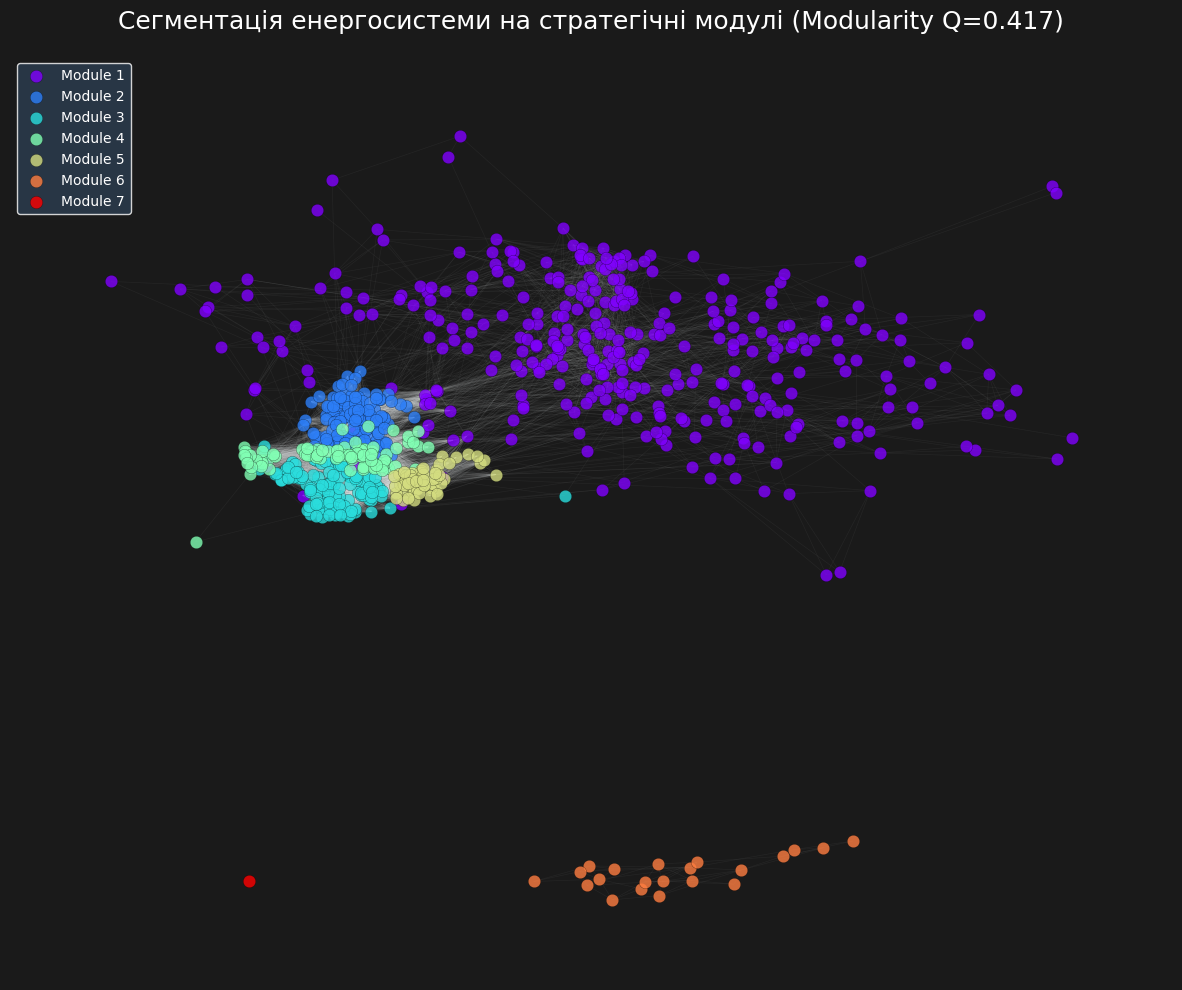


                          АНАЛІЗ СТРАТЕГІЧНИХ МОДУЛІВ                           
📦 Модуль #1 | Вузлів: 342 | Домінанта: S
   🔝 Хаб: W1_(32) (Зношеність та амортизація інфраструктури...)
--------------------------------------------------------------------------------
📦 Модуль #2 | Вузлів: 135 | Домінанта: S
   🔝 Хаб: O3_(45) (Система раннього попередження кіберінцидентів...)
--------------------------------------------------------------------------------
📦 Модуль #3 | Вузлів: 130 | Домінанта: O
   🔝 Хаб: T3_(15) (Тривалі ресурсні, логістичні та фінансові шоки...)
--------------------------------------------------------------------------------
📦 Модуль #4 | Вузлів: 87 | Домінанта: W
   🔝 Хаб: T1__Kindzerska_Anastasiia_KA23 (Повторне ураження ключових вузлів мережі...)
--------------------------------------------------------------------------------
📦 Модуль #5 | Вузлів: 60 | Домінанта: O
   🔝 Хаб: S2_(12) (Диверсифікація палива і джерел генерації...)
-------------------------------------

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities, modularity

# --- 1. ПІДГОТОВКА ТА КЛАСТЕРИЗАЦІЯ ---
G_un = G_integrated.to_undirected()

# Знаходимо спільноти
communities = list(greedy_modularity_communities(G_un, weight='weight'))
q_score = modularity(G_un, communities, weight='weight')

# Створюємо мапу: вузол -> ID спільноти
node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

# --- 2. ВІЗУАЛІЗАЦІЯ (ЯК НА ЗАВДАННІ) ---
plt.figure(figsize=(15, 12), facecolor='#1A1A1A')
ax = plt.gca()
ax.set_facecolor('#1A1A1A')

# Розрахунок позицій вузлів (Force-directed layout)
# k регулює відстань між вузлами (зменште, якщо граф занадто щільний)
pos = nx.spring_layout(G_un, k=0.15, iterations=50, seed=42)

# Палітра кольорів для модулів
colors = plt.cm.rainbow(np.linspace(0, 1, len(communities)))

# Малюємо ребра (тонкі та прозорі, щоб не забивали картинку)
nx.draw_networkx_edges(G_un, pos, alpha=0.05, edge_color='#ecf0f1', width=0.5)

# Малюємо вузли по спільнотах
for i, comm in enumerate(communities):
    nx.draw_networkx_nodes(G_un, pos,
                           nodelist=list(comm),
                           node_size=80,
                           node_color=[colors[i]],
                           label=f"Module {i+1}",
                           alpha=0.8,
                           edgecolors='black',
                           linewidths=0.2)

# Додаємо легенду (обов'язково для МКР)
legend = plt.legend(scatterpoints=1, facecolor='#2c3e50', edgecolor='white', labelcolor='white')
plt.title(f"Сегментація енергосистеми на стратегічні модулі (Modularity Q={q_score:.3f})",
          color='white', fontsize=18, pad=20)
plt.axis('off')
plt.show()

# --- 3. ТЕКСТОВИЙ ЗВІТ (ДОМІНАНТИ) ---
print("\n" + "="*80)
print(f"{'АНАЛІЗ СТРАТЕГІЧНИХ МОДУЛІВ':^80}")
print("="*80)

for i, comm in enumerate(communities):
    nodes = list(comm)
    # Визначаємо домінуючий квадрант за першою літерою ID
    quads = [str(n)[0].upper() for n in nodes]
    dom_quad = max(set(quads), key=quads.count)

    # Пошук ключового фактора модуля (найбільший ступінь у підграфі)
    sub = G_un.subgraph(nodes)
    top_node = max(dict(sub.degree(weight='weight')).items(), key=lambda x: x[1])[0]
    label = next((item['label'] for item in swot_data if item['global_id'] == top_node), "N/A")

    print(f"📦 Модуль #{i+1} | Вузлів: {len(nodes)} | Домінанта: {dom_quad}")
    print(f"   🔝 Хаб: {top_node} ({label[:70]}...)")
    print("-" * 80)

# Threshold-фільтрація

In [ ]:
import numpy as np
import networkx as nx
import pandas as pd
from networkx.algorithms.community import greedy_modularity_communities, modularity

# --- 1. THRESHOLD ФІЛЬТРАЦІЯ ТА ПОРІВНЯННЯ ---
thresholds = [0.20, 0.40, 0.60]
comparison_results = []

print("="*100)
print(f"{'РЕЗУЛЬТАТИ СТРЕС-ТЕСТУВАННЯ ГРАФА (THRESHOLD FILTERING)':^100}")
print("="*100)

for t in thresholds:
    # Фільтрація ребер за вагою
    filtered_edges = [(u, v) for u, v, d in G_integrated.edges(data=True) if abs(d.get('weight', 0)) >= t]
    G_filt = G_integrated.edge_subgraph(filtered_edges).copy()

    # Розрахунок метрик для поточної версії
    scc = [c for c in nx.strongly_connected_components(G_filt) if len(c) > 1]
    mod = modularity(G_filt.to_undirected(), greedy_modularity_communities(G_filt.to_undirected())) if G_filt.number_of_edges() > 0 else 0

    print(f"\n📊 Поріг |w| >= {t:.2f}:")
    print(f"   Ребер вижило: {G_filt.number_of_edges()} з {G_integrated.number_of_edges()}")
    print(f"   Кількість SCC ядер: {len(scc)}")
    print(f"   Модульність (Q): {mod:.4f}")

    # Визначення вижившого ядра (найбільша SCC)
    if scc:
        main_core = max(scc, key=len)
        core_labels = [str(n)[0].upper() for n in main_core]
        print(f"   🔝 Ядро мережі ({len(main_core)} вузлів): { {q: core_labels.count(q) for q in set(core_labels)} }")

# --- 2. КАСКАДНИЙ АНАЛІЗ (K-STEP INFLUENCE) ---
# Створюємо матрицю суміжності з вагами
W = nx.to_numpy_array(G_integrated, weight='weight')
nodes_list = list(G_integrated.nodes())

# Рахуємо матриці непрямих впливів (k=3)
W3 = np.linalg.matrix_power(W, 3)

# Сумуємо вплив
total_inf_k1 = np.sum(np.abs(W), axis=1)
total_inf_k3 = np.sum(np.abs(W3), axis=1)

print("\n" + "="*100)
print(f"{'АНАЛІЗ СЛАБКИХ СИГНАЛІВ (K-STEP CASCADE)':^100}")
print("="*100)

weak_signals = []
mean_k1 = np.mean(total_inf_k1)
mean_k3 = np.mean(total_inf_k3)

for i, node in enumerate(nodes_list):
    # Логіка: прямий вплив малий, але каскадний - великий
    if total_inf_k1[i] < mean_k1 and total_inf_k3[i] > mean_k3:
        label = next((item['label'] for item in swot_data if item['global_id'] == node), "N/A")
        weak_signals.append({
            'Node': node,
            'K1': total_inf_k1[i],
            'K3': total_inf_k3[i],
            'Label': label
        })

if weak_signals:
    for sig in sorted(weak_signals, key=lambda x: x['K3'], reverse=True)[:5]:
        print(f"🔍 Вузол {sig['Node']} — СЛАБКИЙ СИГНАЛ:")
        print(f"   Прямий вплив (1 крок): {sig['K1']:.3f}")
        print(f"   Непрямий каскад (3 кроки): {sig['K3']:.3f}")
        print(f"   Зміст: {sig['Label'][:80]}...\n")
else:
    print("Слабких сигналів із заданими критеріями не виявлено.")

                      РЕЗУЛЬТАТИ СТРЕС-ТЕСТУВАННЯ ГРАФА (THRESHOLD FILTERING)                       

📊 Поріг |w| >= 0.20:
   Ребер вижило: 52631 з 52658
   Кількість SCC ядер: 5
   Модульність (Q): 0.3916
   🔝 Ядро мережі (739 вузлів): {'W': 178, 'O': 180, 'T': 179, 'S': 202}

📊 Поріг |w| >= 0.40:
   Ребер вижило: 1260 з 52658
   Кількість SCC ядер: 48
   Модульність (Q): 0.9724
   🔝 Ядро мережі (16 вузлів): {'W': 4, 'O': 4, 'T': 4, 'S': 4}

📊 Поріг |w| >= 0.60:
   Ребер вижило: 770 з 52658
   Кількість SCC ядер: 37
   Модульність (Q): 0.9755
   🔝 Ядро мережі (11 вузлів): {'W': 3, 'O': 2, 'T': 3, 'S': 3}

                              АНАЛІЗ СЛАБКИХ СИГНАЛІВ (K-STEP CASCADE)                              
🔍 Вузол O3_(12) — СЛАБКИЙ СИГНАЛ:
   Прямий вплив (1 крок): 20.645
   Непрямий каскад (3 кроки): 34537.020
   Зміст: Громадське управління розподіленою генерацією...

🔍 Вузол W3_(35) — СЛАБКИЙ СИГНАЛ:
   Прямий вплив (1 крок): 20.800
   Непрямий каскад (3 кроки): 34505.316
   Зміст: С